## This notebook allows visualizing the different DEGs from DESeq2 and analysing their effect for Breast data

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score,  silhouette_samples
import random

## Load Data

In [3]:
input_file = "DESeq2Local/DESeq2Input/breastCounts.csv"
sample_clinical_file = "Datasets/DESeq2Input/breastSampleToClinicalFeatures.csv"
sample_clinical = pd.read_csv(sample_clinical_file)

In [4]:
df = pd.read_csv(input_file)
df.index = df['gene_id']
df = df.drop('gene_id', axis = 1)

In [5]:
df

,2c3000b7-4db9-4f00-a82a-ca6802806631,519b92e0-0dbc-471c-988f-48ce9dc95be3,f2bf29d2-4c33-4810-90e8-88f37ea47bc8,59858555-bc6a-4286-8280-0f8341123cac,de6f1503-33d7-4f86-b835-bdffba7ea4e3,f0a63361-78bb-4a7f-9d78-31f7b2980ba2,121a48ed-798d-4102-bb8f-e736570e18d6,afedbcf7-d427-4371-9c2a-f349b03de522,82004d79-07d3-4a01-b266-4d36353ba561,4e98f490-cbdf-4864-8cc3-b5f9d3c95146,...,1ce0d66a-176d-4d8a-b1c4-64d847e299be,d757b1cc-31a6-495a-ae82-c63b031ece49,e84b9f1a-0def-425b-86c1-c143b27509b5,b9a1e2f1-e5c4-4855-9720-4c168474dd26,fd94a0ed-37d8-49a5-af96-e2160a9e6096,5e789924-9d98-4765-a348-90a27349d906,8a84b9a5-d453-416b-b481-f15402c2eb54,ccb87d7a-2729-4017-bc17-10e5a67bd5cc,040d00da-2bc9-49d4-bf6c-b4515b6a2bbf,8ebe0bf6-11fa-418d-918c-5c73f0e7e9ac
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,2304.0,1033.0,2967.0,9201.0,1162.0,745.0,2651.0,2683.0,3006.0,1073.0,...,5824,7064,9160,4943,4472,4816,2829,3542,3116,6854
ENSG00000000005.6,7.0,4.0,17.0,9.0,90.0,0.0,162.0,96.0,37.0,0.0,...,498,1899,879,1038,692,308,240,327,817,318
ENSG00000000419.13,4979.0,2240.0,5568.0,4186.0,1703.0,1537.0,1096.0,2728.0,2278.0,2116.0,...,2422,2680,4066,1766,1428,2279,1067,1504,1408,3435
ENSG00000000457.14,1544.0,1702.0,3458.0,2054.0,1401.0,1798.0,1701.0,1765.0,2518.0,868.0,...,1695,1626,2022,1562,1107,1086,928,705,954,2107
ENSG00000000460.17,1723.0,587.0,2060.0,4333.0,876.0,497.0,532.0,624.0,644.0,392.0,...,409,527,762,390,218,294,255,226,125,698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288667.1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,0,0,0
ENSG00000288669.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,2,0,0,1,1,0,0,0,0
ENSG00000288670.1,256.0,458.0,1024.0,741.0,197.0,207.0,219.0,336.0,402.0,455.0,...,618,645,584,574,526,292,295,248,253,653


In [6]:
sample_clinical.index = sample_clinical["Unnamed: 0"]
sample_clinical = sample_clinical.drop("Unnamed: 0", axis = 1)

In [7]:
sample_subset = list(df.columns)
sample_clinical = sample_clinical.loc[sample_subset]

In [8]:
sample_clinical.shape

(1231, 10)

In [19]:
sample_clinical

,Case ID,cases.submitter_id,cases.disease_type,demographic.gender,demographic.age_at_index,demographic.race,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.primary_diagnosis,diagnosis_grouped
Unnamed: 0,,,,,,,,,,
2c3000b7-4db9-4f00-a82a-ca6802806631,TCGA-C8-A1HM,TCGA-C8-A1HM,Ductal and Lobular Neoplasms,female,74,asian,Stage IIA,primary,"Infiltrating duct carcinoma, NOS",Infiltrating Ductal Carcinoma
519b92e0-0dbc-471c-988f-48ce9dc95be3,TCGA-A8-A08S,TCGA-A8-A08S,Ductal and Lobular Neoplasms,female,71,not reported,'--,Prior primary,Not Reported,Not Reported
f2bf29d2-4c33-4810-90e8-88f37ea47bc8,TCGA-AR-A24H,TCGA-AR-A24H,Ductal and Lobular Neoplasms,female,65,white,Stage IIA,primary,"Lobular carcinoma, NOS",Infiltrating Lobular Carcinoma
59858555-bc6a-4286-8280-0f8341123cac,TCGA-AR-A1AH,TCGA-AR-A1AH,Ductal and Lobular Neoplasms,female,51,white,'--,Subsequent Primary,Not Reported,Not Reported
de6f1503-33d7-4f86-b835-bdffba7ea4e3,TCGA-BH-A0BC,TCGA-BH-A0BC,Ductal and Lobular Neoplasms,female,60,white,Stage IIIC,primary,"Infiltrating duct carcinoma, NOS",Infiltrating Ductal Carcinoma
...,...,...,...,...,...,...,...,...,...,...
5e789924-9d98-4765-a348-90a27349d906,TCGA-GI-A2C9,TCGA-GI-A2C9,NA/Normal Sample,female,58,black or african american,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
8a84b9a5-d453-416b-b481-f15402c2eb54,TCGA-BH-A1EU,TCGA-BH-A1EU,NA/Normal Sample,female,83,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
ccb87d7a-2729-4017-bc17-10e5a67bd5cc,TCGA-E2-A15M,TCGA-E2-A15M,NA/Normal Sample,female,66,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample


In [9]:
def plot_silhouette(sil_df):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=sil_df, x='label', y='silhouette', hue='label', palette='Set2', legend=False)
    plt.axhline(0, linestyle='--', color='gray')
    plt.title("Silhouette scores by condition/subtype")
    plt.ylabel("Silhouette value")
    plt.xlabel("Label")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Gene Subsets and Visualizations

In [10]:
base_dir = Path("DESeq2Local/results/DiagnosisGrouped_Breast/CancerToNormal")
all_cancer_to_normal_sig_genes = set()

In [11]:
for subfolder in base_dir.iterdir():
    if subfolder.is_dir():
        sig_file = subfolder / "sig_genes.csv"
        if sig_file.exists():
            df_genes = pd.read_csv(sig_file, index_col=0)  # assuming gene names are rownames
            print(len(df_genes))
            all_cancer_to_normal_sig_genes.update(df_genes.index.tolist())


4483
5230
5632
5676
4726


In [12]:
len(all_cancer_to_normal_sig_genes)

9084

In [13]:
base_dir = Path("DESeq2Local/results/DiagnosisGrouped_Breast/CancerSTtoST")
all_cancer_to_cancer_sig_genes = set()

In [14]:
for subfolder in base_dir.iterdir():
    if subfolder.is_dir():
        sig_file = subfolder / "sig_genes.csv"
        if sig_file.exists():
            df_genes = pd.read_csv(sig_file, index_col=0)  # assuming gene names are rownames
            print(len(df_genes))
            all_cancer_to_cancer_sig_genes.update(df_genes.index.tolist())


1373


In [15]:
len(all_cancer_to_cancer_sig_genes)

1373

In [16]:
intersection_sig_genes = all_cancer_to_normal_sig_genes.intersection(all_cancer_to_cancer_sig_genes)
len(intersection_sig_genes)

1319

In [17]:
union_sig_genes = all_cancer_to_normal_sig_genes.union(all_cancer_to_cancer_sig_genes)
len(union_sig_genes)

9138

In [32]:
columns_to_group_dict = {
    'Gender' : 'demographic.gender',
    'Age': 'demographic.age_at_index',
    'Race': 'demographic.race',
    #'Disease Type' : 'cases.disease_type',
    'Grouped Diagnosis': 'diagnosis_grouped',
    # 'Pathologic Stage': 'diagnoses.ajcc_pathologic_stage',
    # 'Classification of Tumor' :'diagnoses.classification_of_tumor',
    # 'Primary Diagnosis': 'diagnoses.primary_diagnosis',
}

In [27]:
def save_pca_plot(pca_df, explained, hue, title, filename, save = True):
    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=hue, palette='Set2', s=60)
    plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    box = scatter.get_position()
    scatter.set_position([box.x0, box.y0, box.width * 0.8, box.height])  # Shrink plot
    plt.legend(
        title="Categories",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.,
        ncol=2,  # Two-column legend
        fontsize='small',
        title_fontsize='medium'
    )
    if save: 
        plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

## All genes

In [28]:
df_for_pca = df.T
log_norm_df = np.log2(df_for_pca + 1)

In [29]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

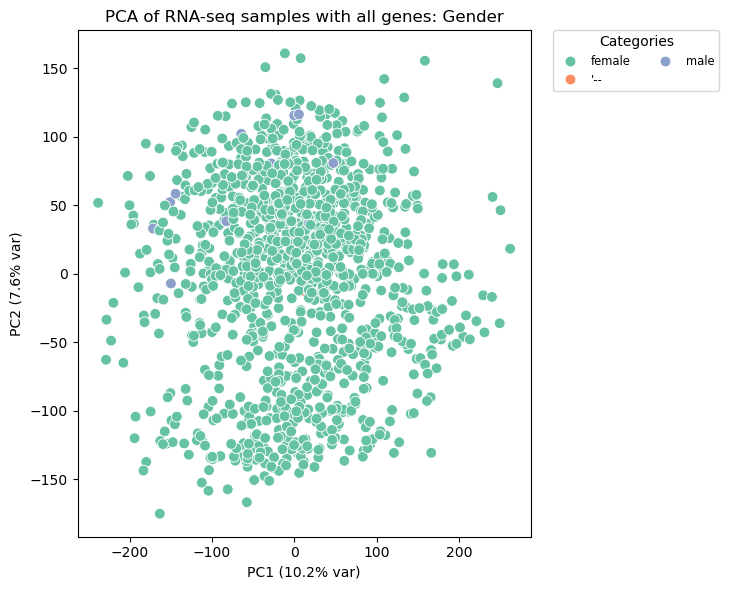

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


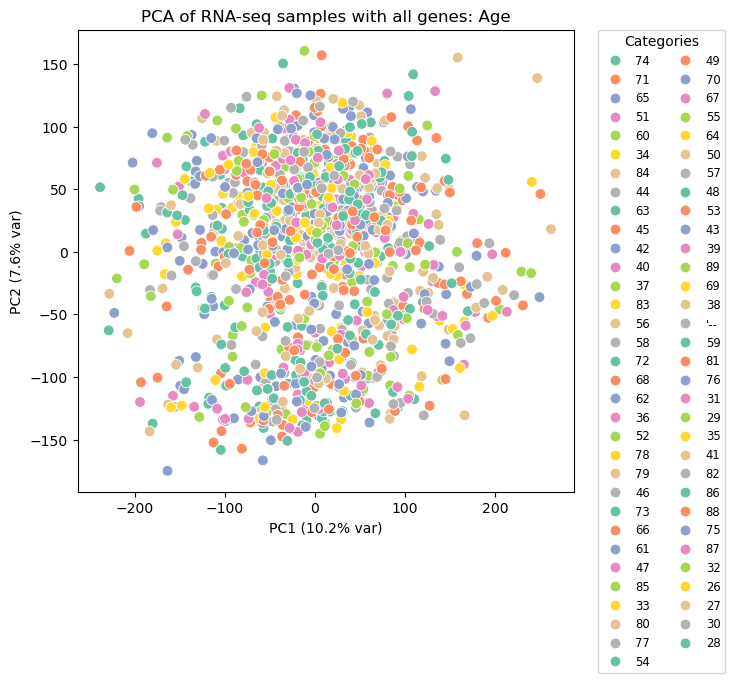

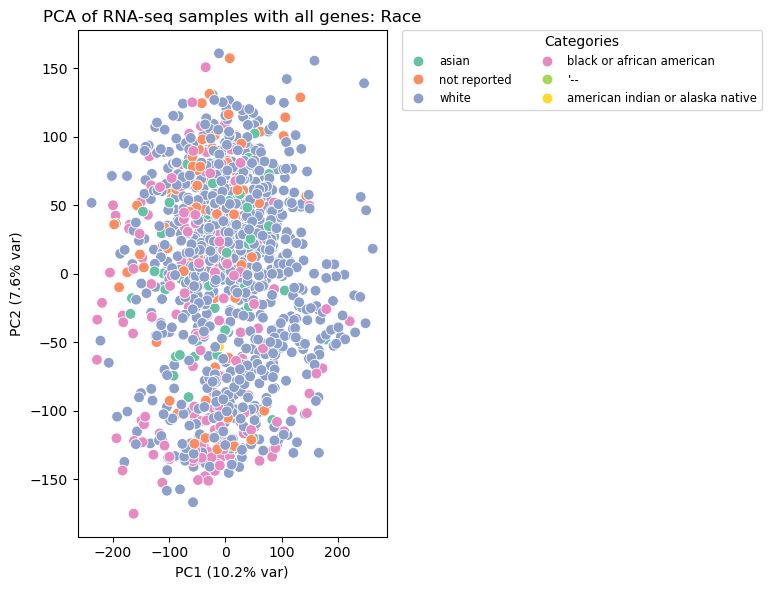

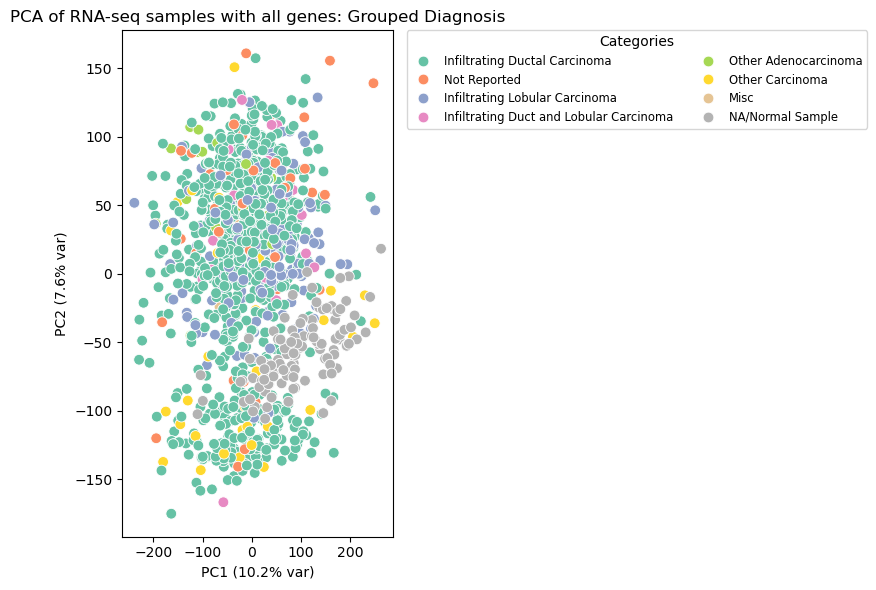

In [33]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples with all genes: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [34]:
X = PCA(n_components=10).fit_transform(log_norm_df)
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.251
Silhouette Score of Labelling Age: -0.370
Silhouette Score of Labelling Race: -0.249
Silhouette Score of Labelling Grouped Diagnosis: -0.071


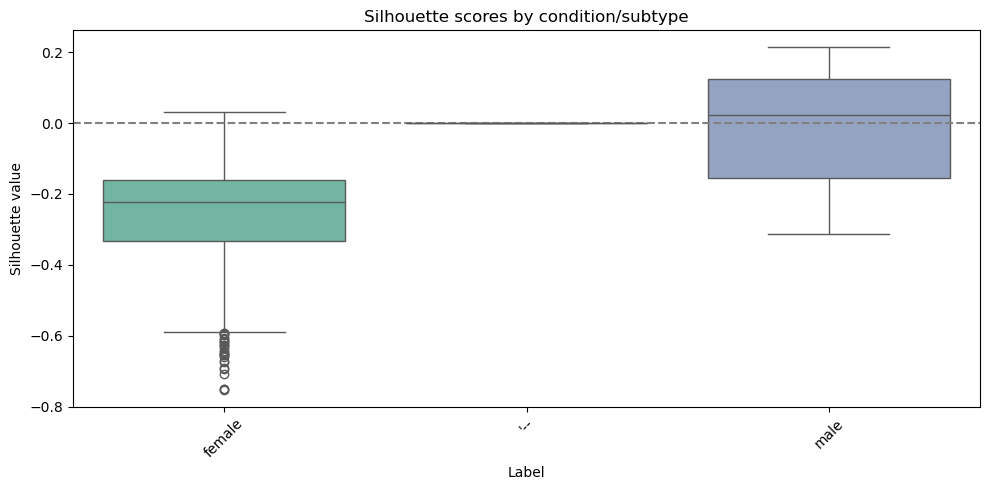

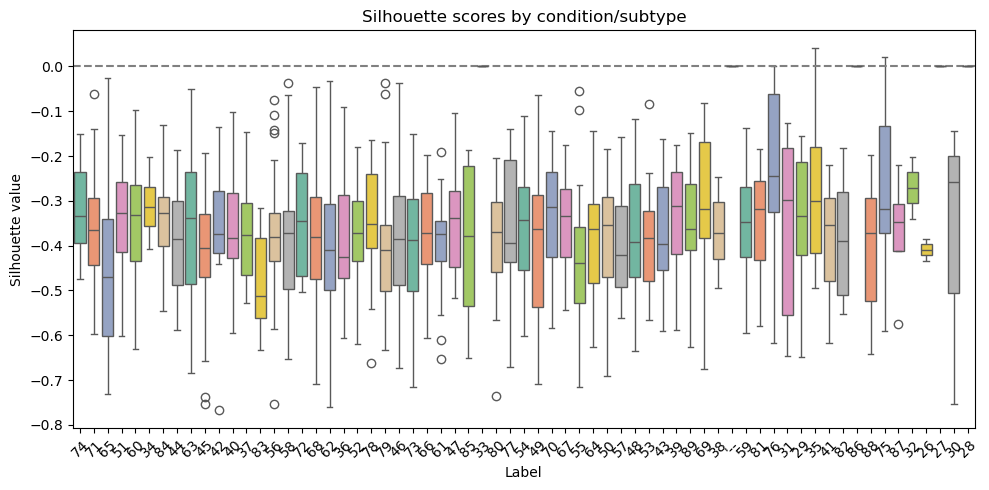

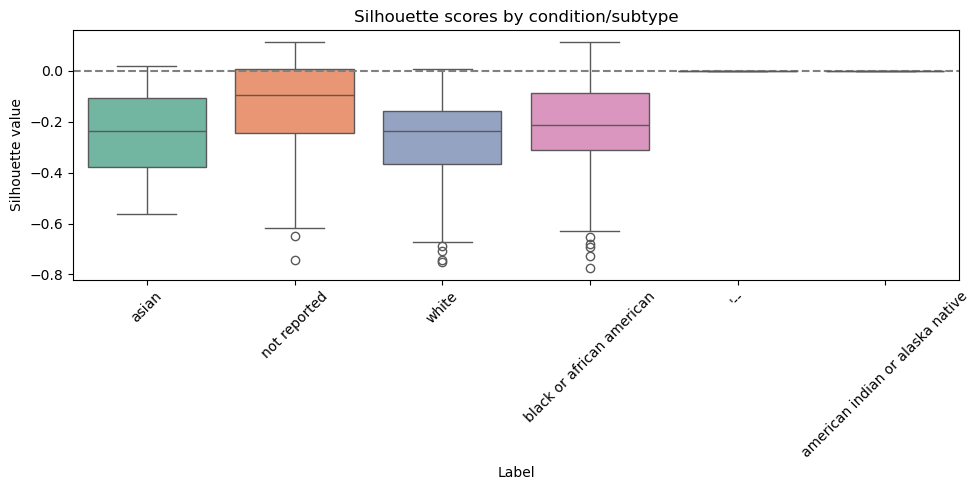

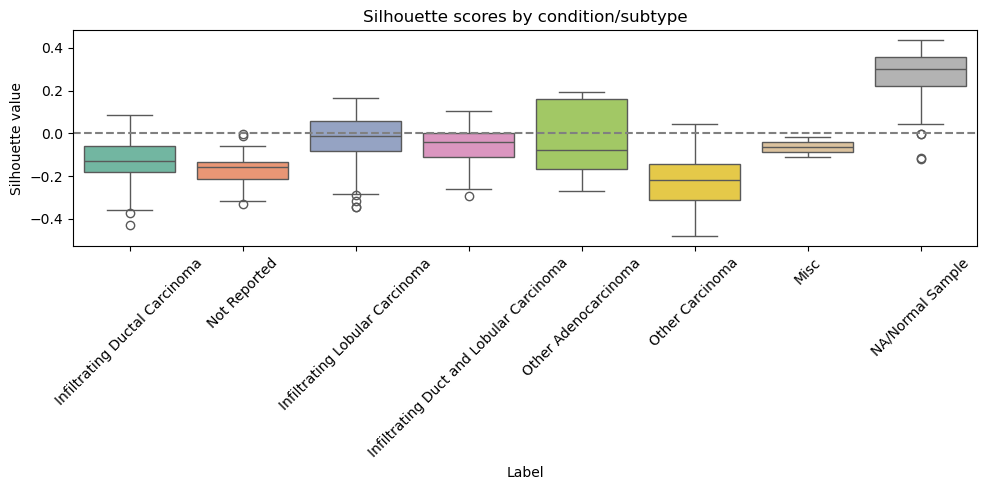

In [35]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## All genes DE from normal samples

In [37]:
with open('Datasets/BreastSigGenes/cancer_to_normal_comparison_sig_genes.txt', 'w') as f:
    for item in list(all_cancer_to_normal_sig_genes):
        f.write(f"{item}\n")

In [38]:
df_cancer_to_normal = df.loc[list(all_cancer_to_normal_sig_genes)].copy()

In [39]:
df_for_pca = df_cancer_to_normal.T
log_norm_df = np.log2(df_for_pca + 1)

In [40]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [41]:
pca_df

,PC1,PC2,Gender,Age,Race,Grouped Diagnosis
0,-70.874908,-34.381900,female,74,asian,Infiltrating Ductal Carcinoma
1,-47.513528,20.687433,female,71,not reported,Not Reported
2,-37.302566,2.224423,female,65,white,Infiltrating Lobular Carcinoma
3,-3.489814,-90.509339,female,51,white,Not Reported
4,10.873657,24.769912,female,60,white,Infiltrating Ductal Carcinoma
...,...,...,...,...,...,...
1226,142.051453,18.375082,female,58,black or african american,NA/Normal Sample
1227,95.132747,28.244226,female,83,white,NA/Normal Sample
1228,113.708052,42.318475,female,66,white,NA/Normal Sample
1229,87.511806,21.642618,female,48,white,NA/Normal Sample


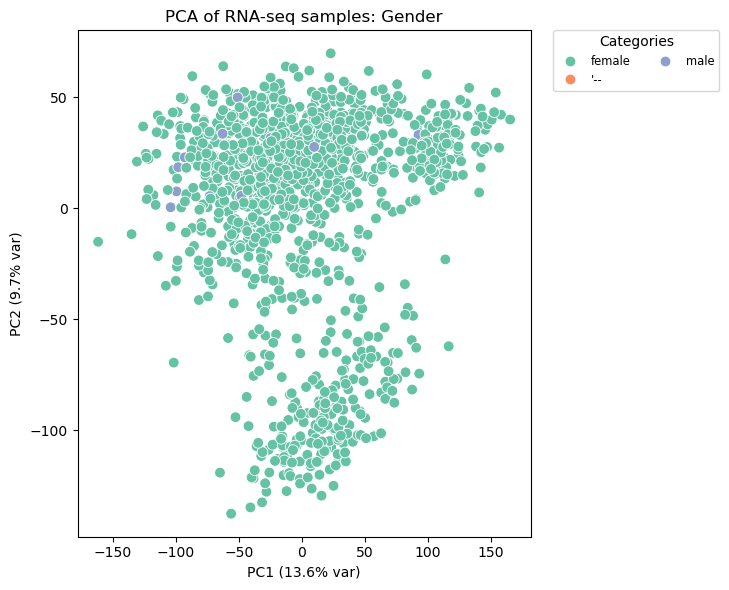

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


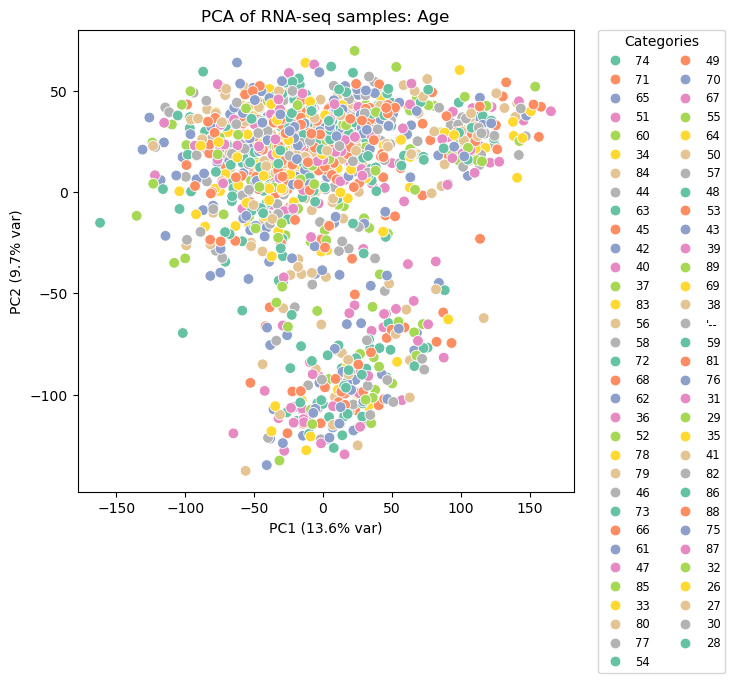

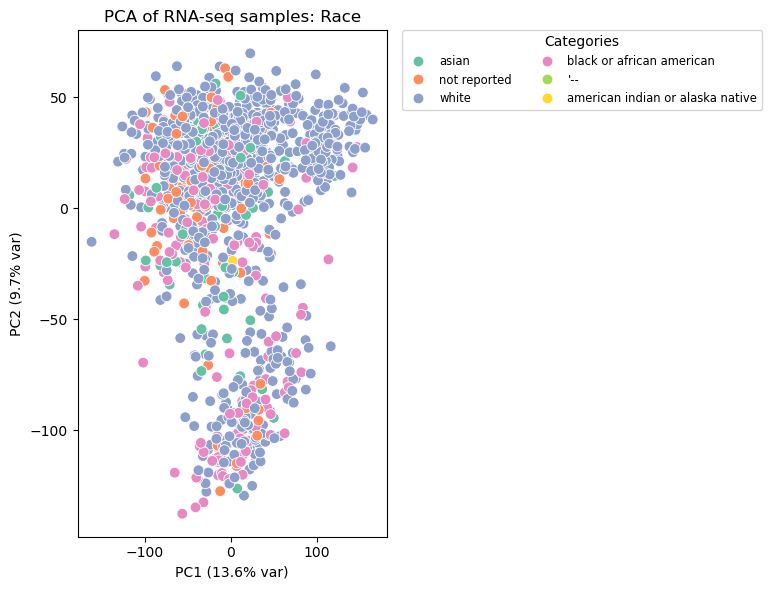

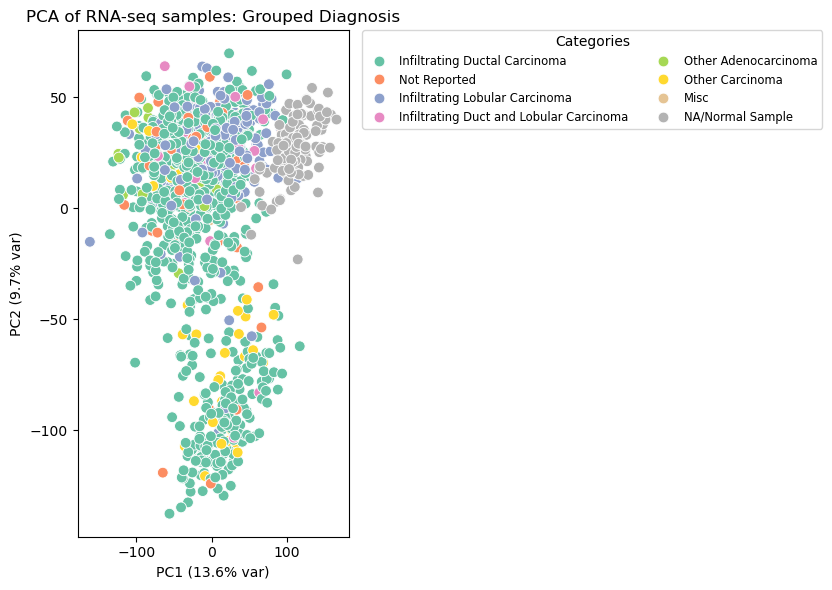

In [42]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [43]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.250
Silhouette Score of Labelling Age: -0.364
Silhouette Score of Labelling Race: -0.251
Silhouette Score of Labelling Grouped Diagnosis: -0.080


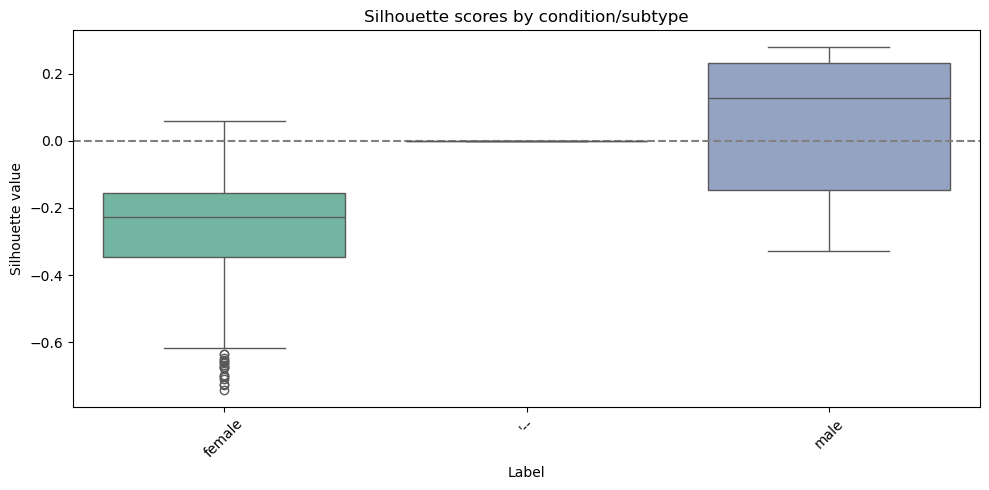

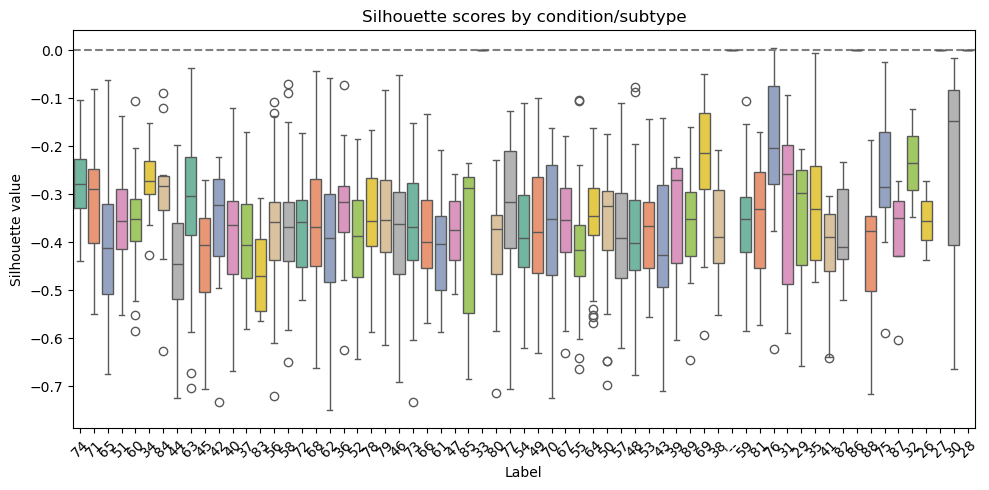

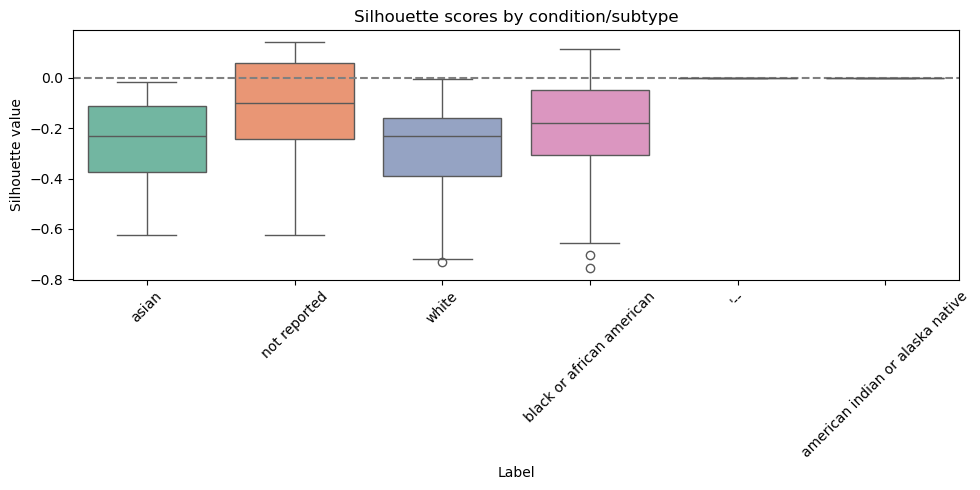

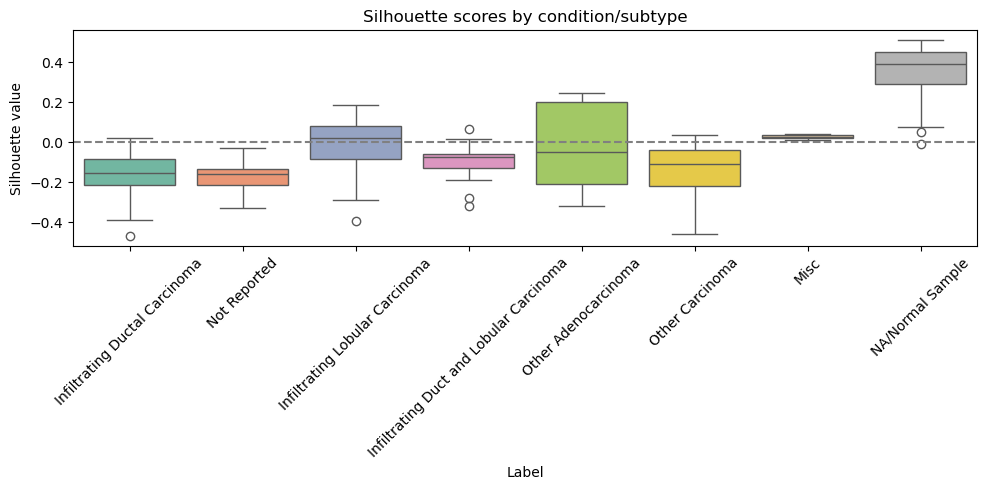

In [44]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## All genes DE cancer to cancer

In [45]:
with open('Datasets/BreastSigGenes/cancer_to_cancer_comparison_sig_genes.txt', 'w') as f:
    for item in list(all_cancer_to_cancer_sig_genes):
        f.write(f"{item}\n")

In [46]:
df_cancer_to_cancer = df.loc[list(all_cancer_to_cancer_sig_genes)].copy()

In [47]:
df_for_pca = df_cancer_to_cancer.T
log_norm_df = np.log2(df_for_pca + 1)

In [48]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [49]:
pca_df

,PC1,PC2,Gender,Age,Race,Grouped Diagnosis
0,-22.014295,-36.102208,female,74,asian,Infiltrating Ductal Carcinoma
1,-19.514193,-19.472390,female,71,not reported,Not Reported
2,-13.809539,-22.558062,female,65,white,Infiltrating Lobular Carcinoma
3,30.798630,-33.527800,female,51,white,Not Reported
4,-4.116196,9.823997,female,60,white,Infiltrating Ductal Carcinoma
...,...,...,...,...,...,...
1226,47.802700,55.308448,female,58,black or african american,NA/Normal Sample
1227,16.124143,56.529537,female,83,white,NA/Normal Sample
1228,17.541149,65.328545,female,66,white,NA/Normal Sample
1229,25.460989,61.116432,female,48,white,NA/Normal Sample


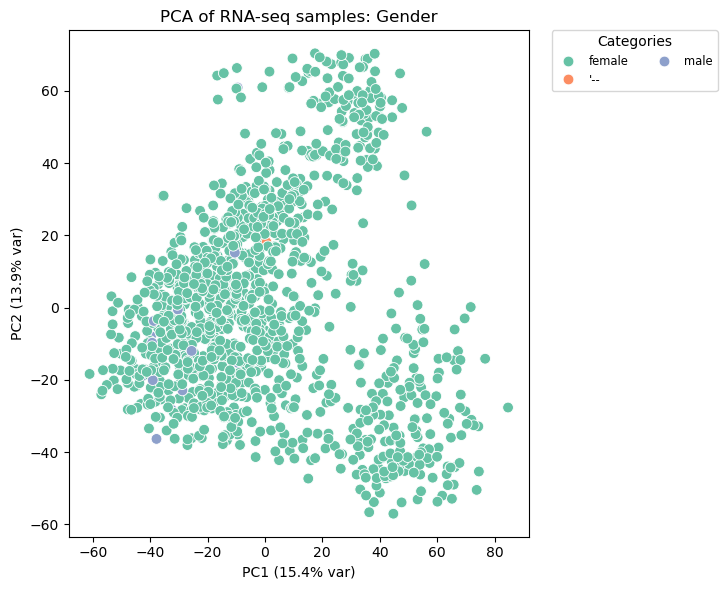

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


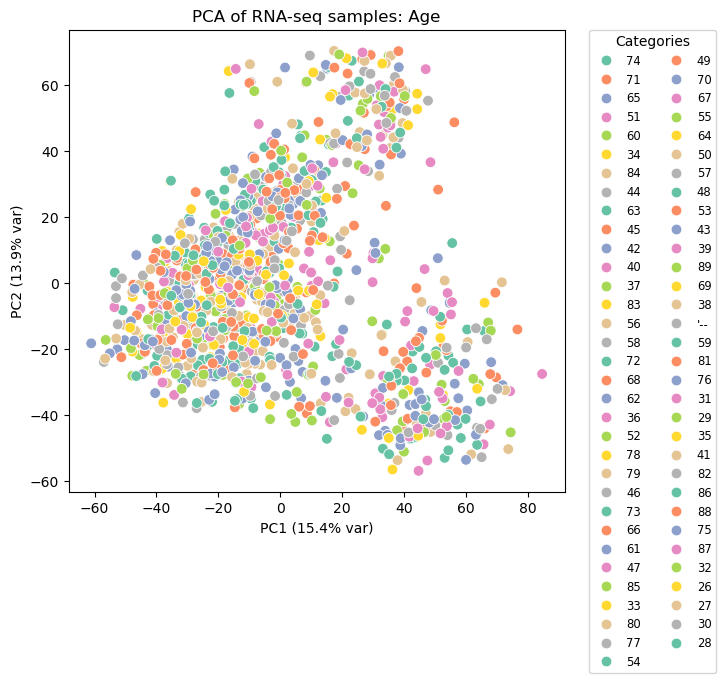

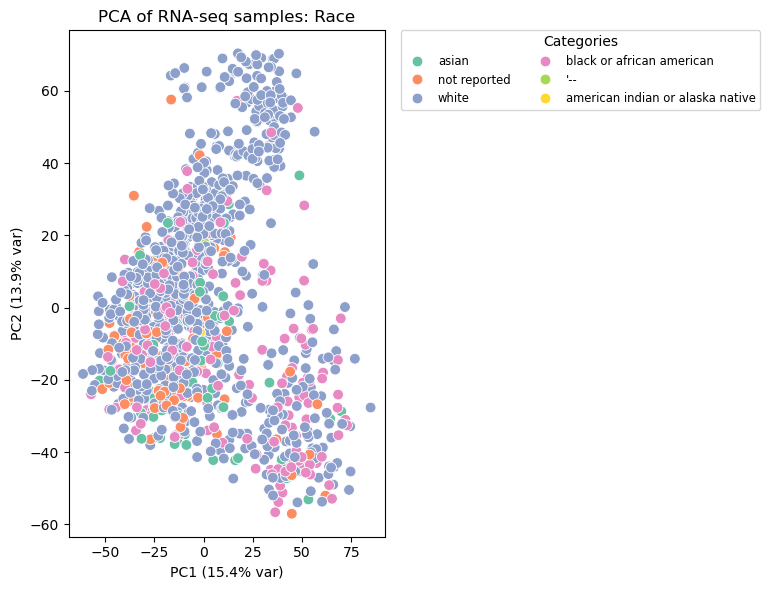

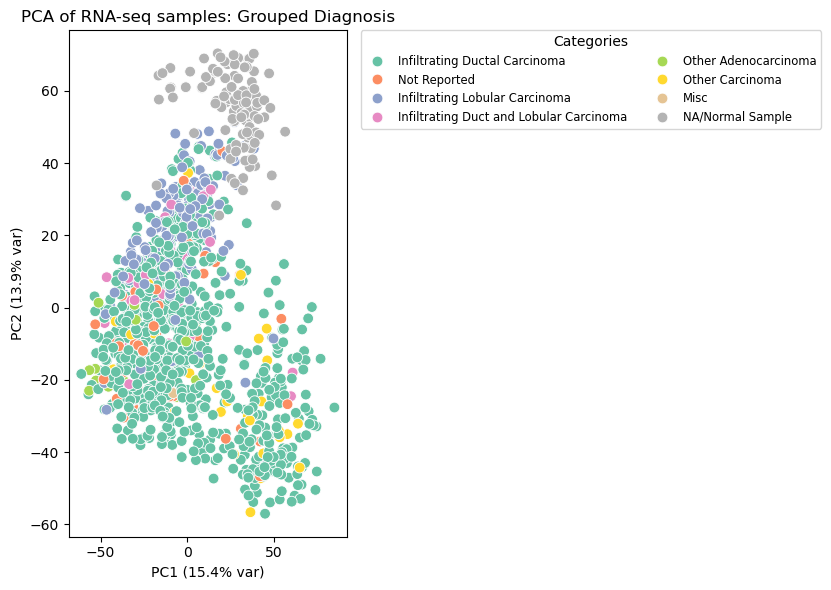

In [50]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [51]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.281
Silhouette Score of Labelling Age: -0.385
Silhouette Score of Labelling Race: -0.273
Silhouette Score of Labelling Grouped Diagnosis: -0.079


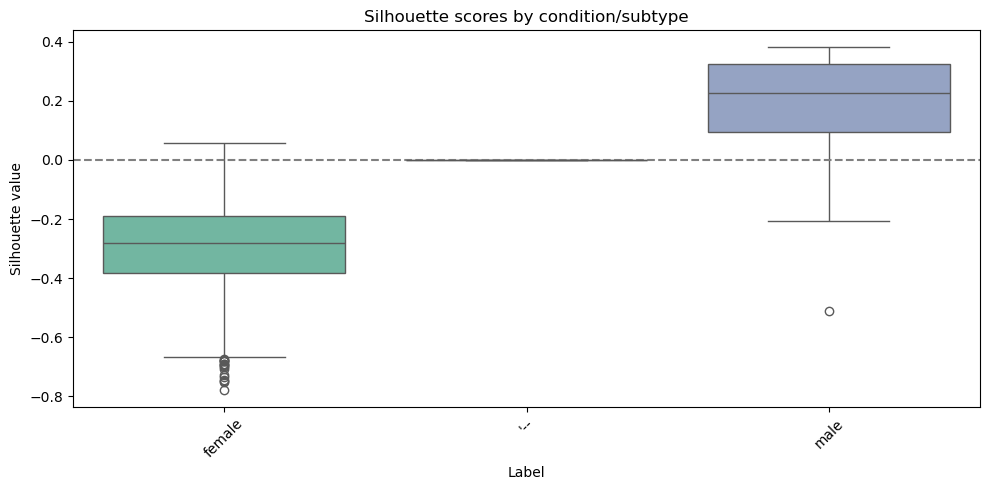

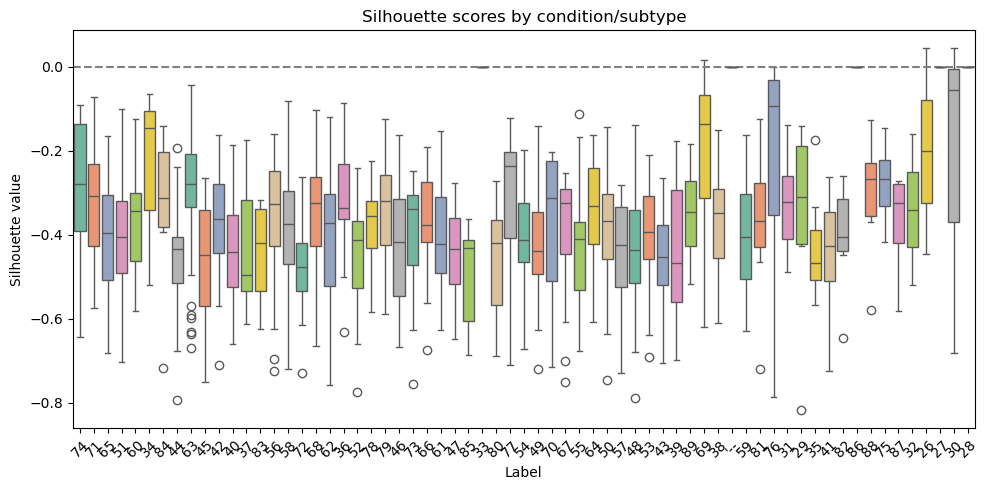

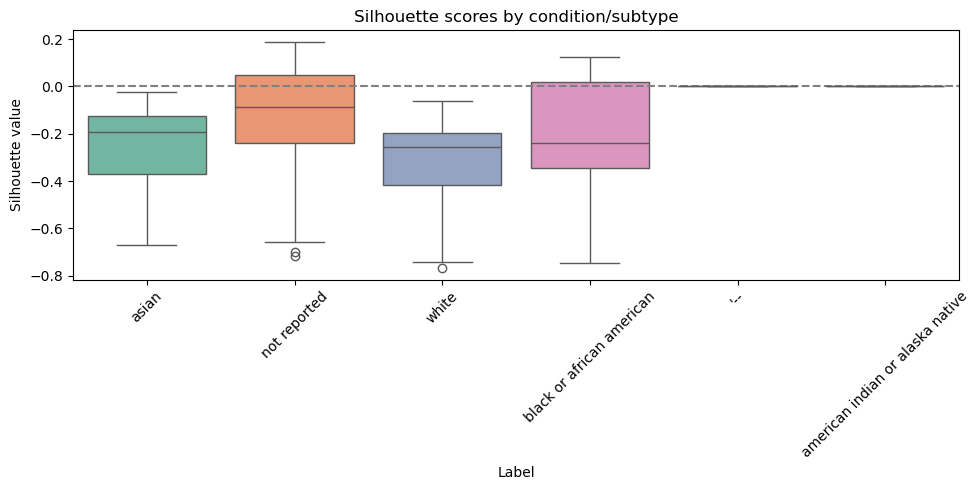

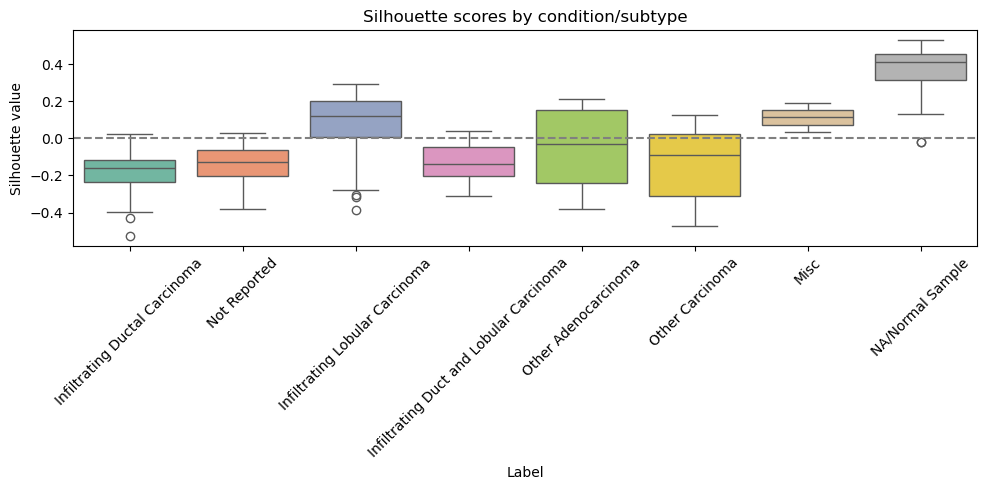

In [52]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Intersection gene set

In [53]:
with open('Datasets/LungSigGenes/intersection_sig_genes.txt', 'w') as f:
    for item in list(intersection_sig_genes):
        f.write(f"{item}\n")

In [54]:
df_intersection = df.loc[list(intersection_sig_genes)].copy()


In [55]:
df_for_pca = df_intersection.T
log_norm_df = np.log2(df_for_pca + 1)

In [56]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

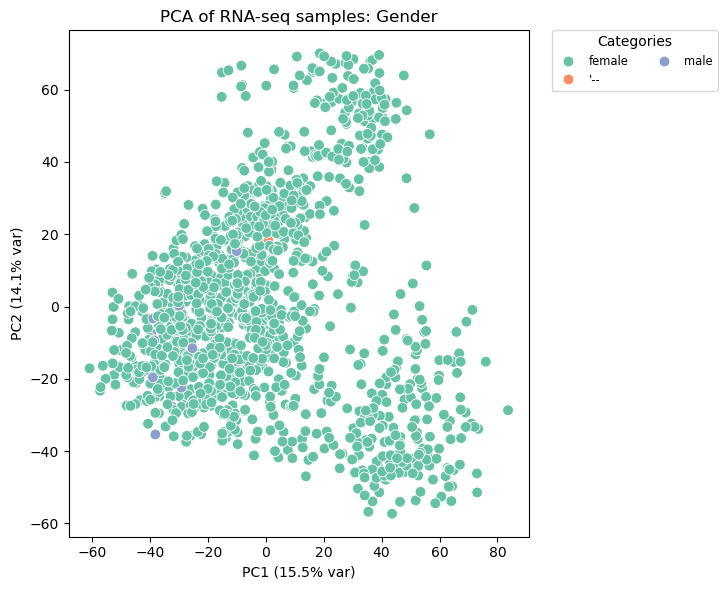

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


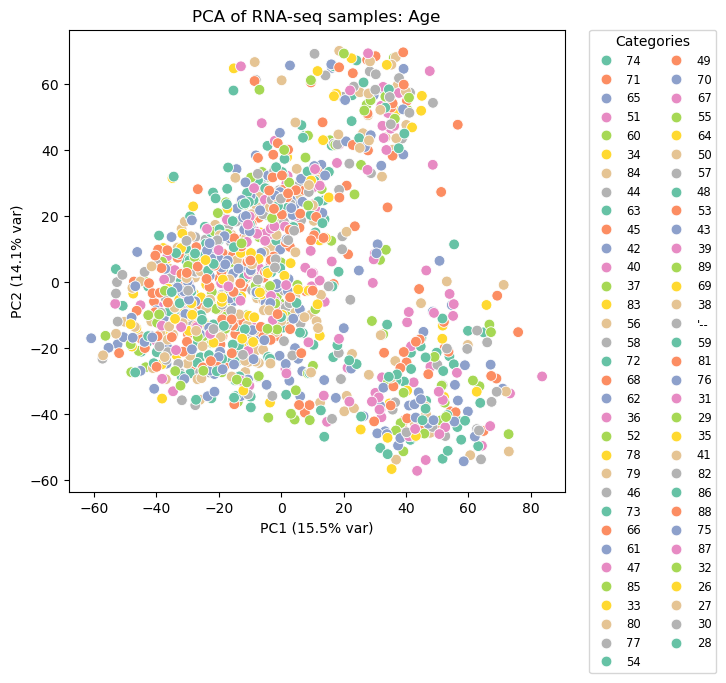

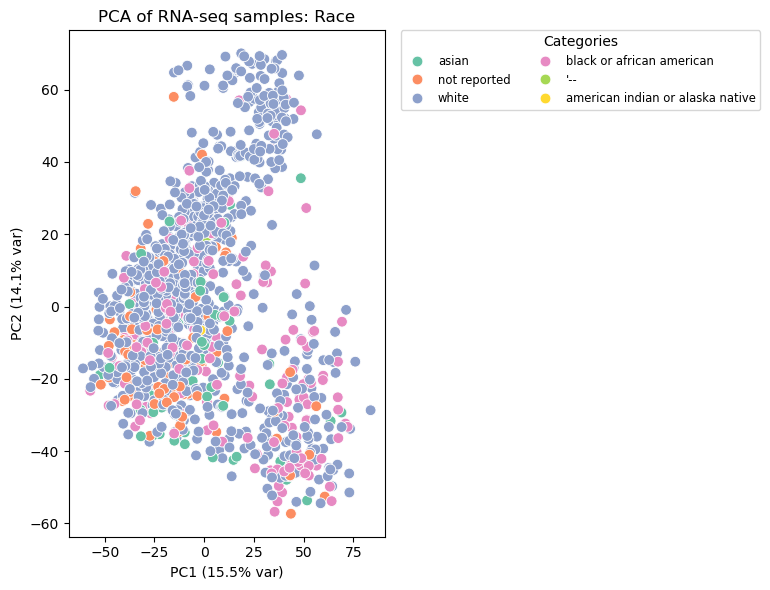

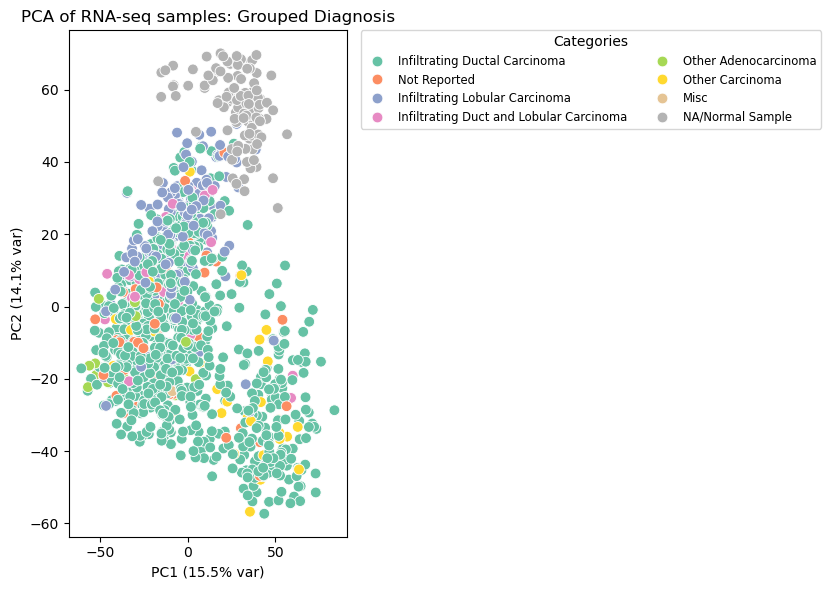

In [57]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [58]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.282
Silhouette Score of Labelling Age: -0.384
Silhouette Score of Labelling Race: -0.273
Silhouette Score of Labelling Grouped Diagnosis: -0.078


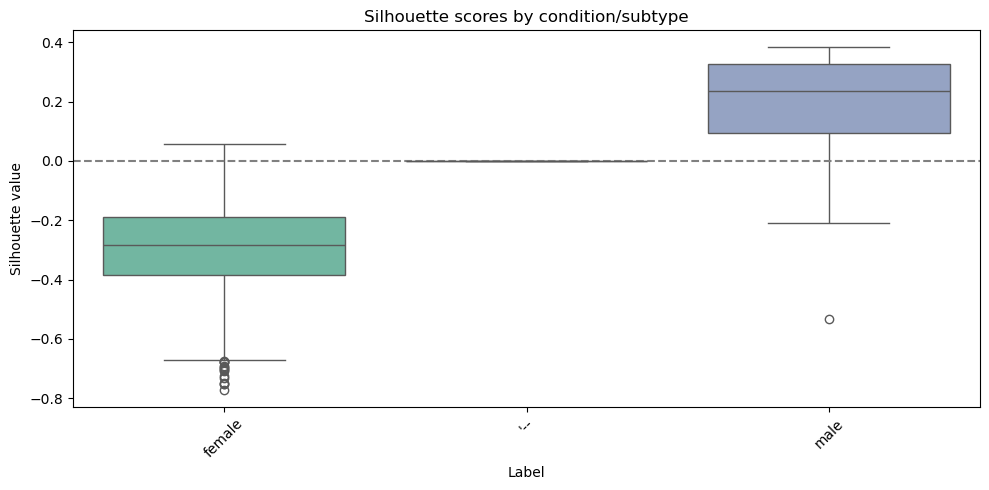

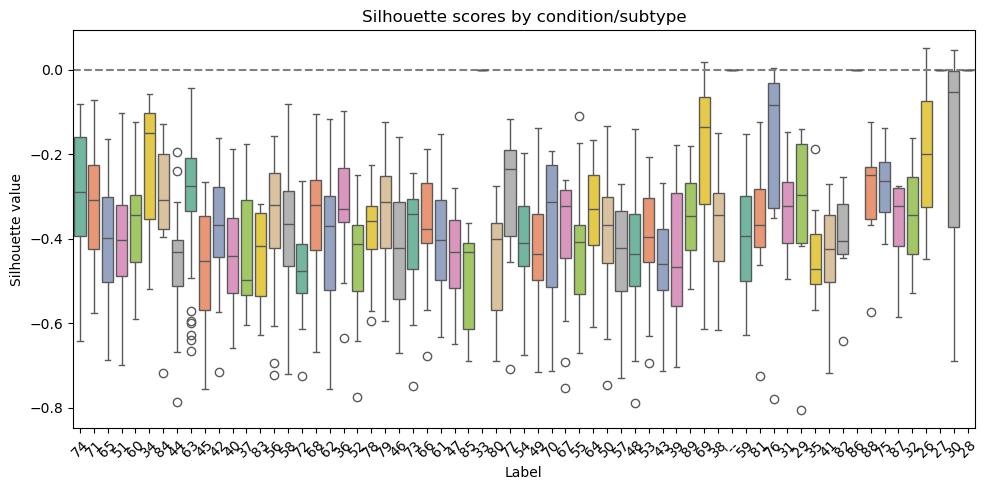

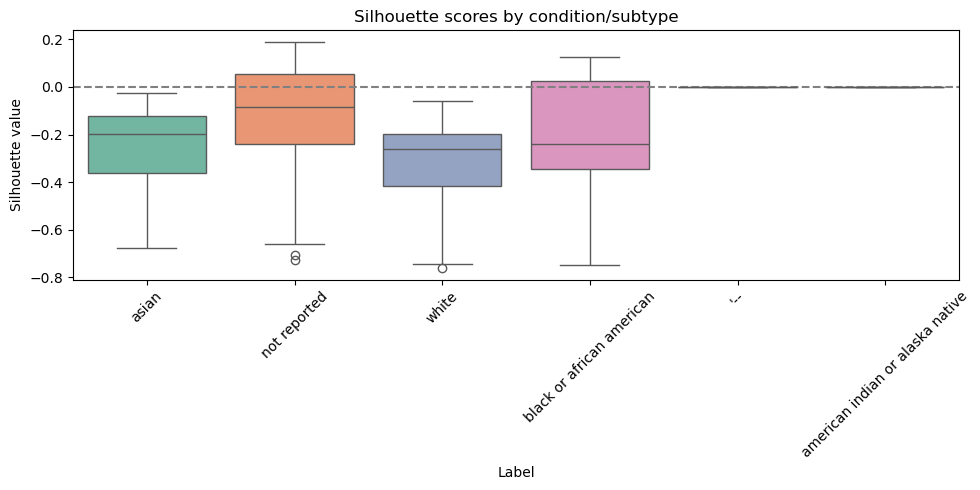

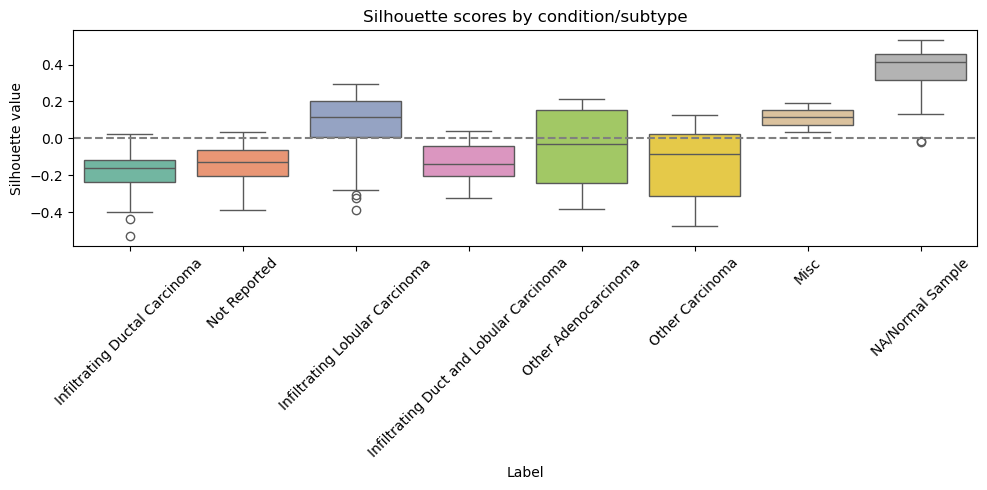

In [59]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Union Gene set

In [60]:
with open('Datasets/LungSigGenes/union_sig_genes.txt', 'w') as f:
    for item in list(union_sig_genes):
        f.write(f"{item}\n")

In [61]:
df_union = df.loc[list(union_sig_genes)].copy()

In [62]:
df_for_pca = df_union.T
log_norm_df = np.log2(df_for_pca + 1)

In [63]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

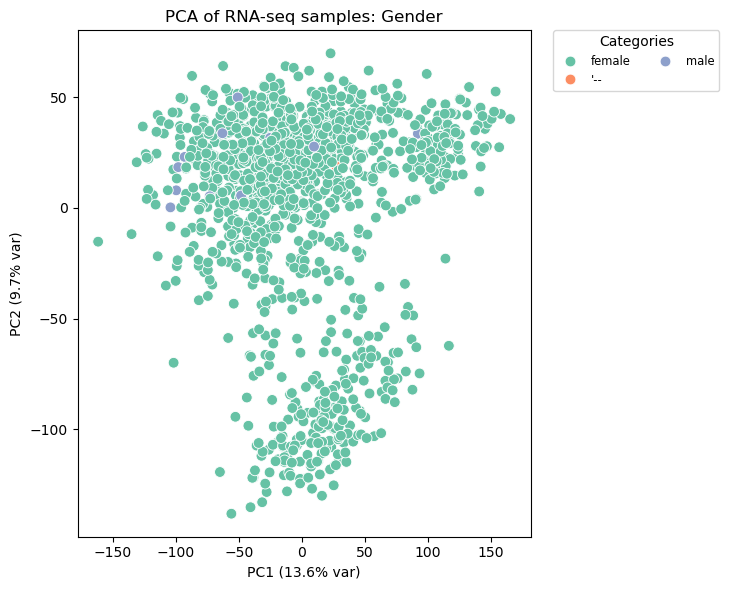

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


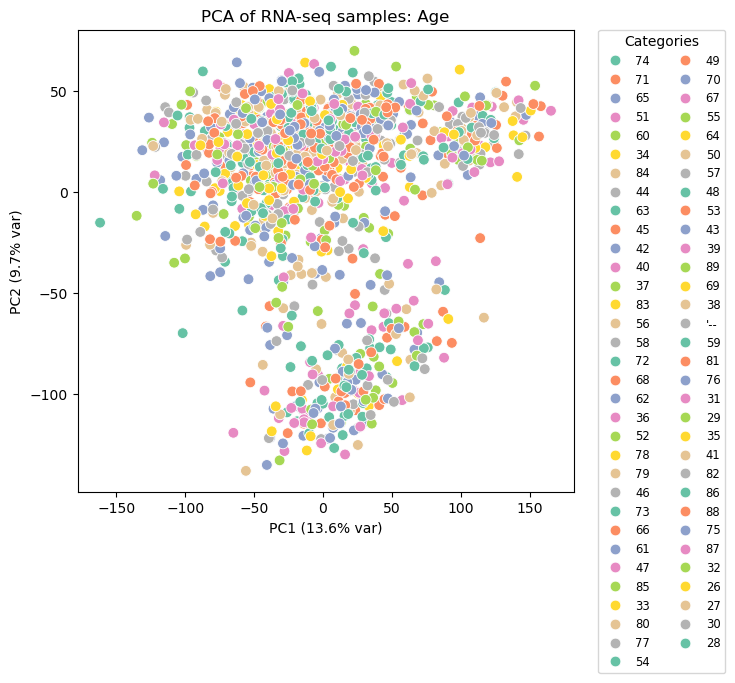

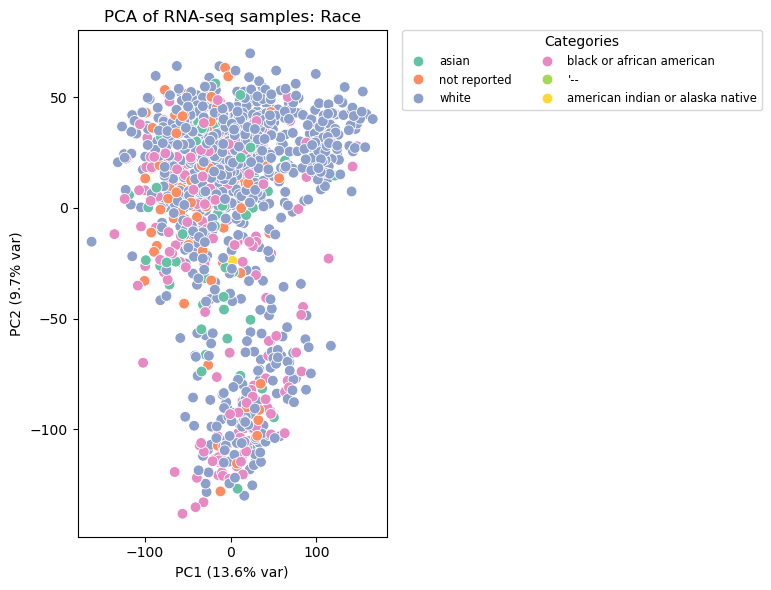

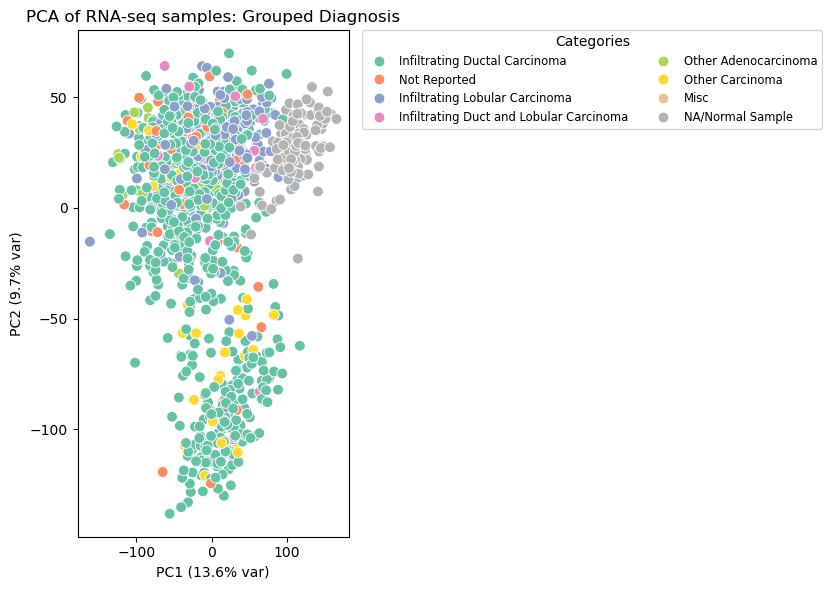

In [64]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [65]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.250
Silhouette Score of Labelling Age: -0.364
Silhouette Score of Labelling Race: -0.251
Silhouette Score of Labelling Grouped Diagnosis: -0.079


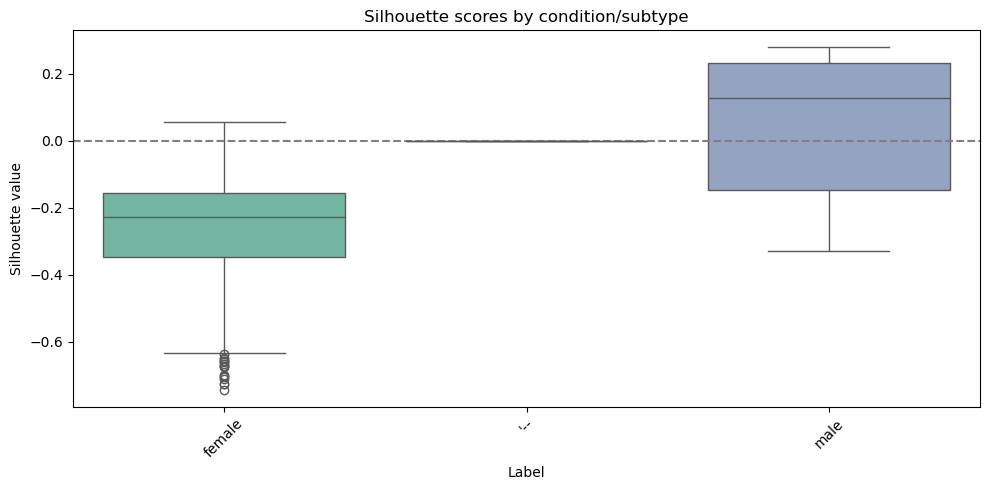

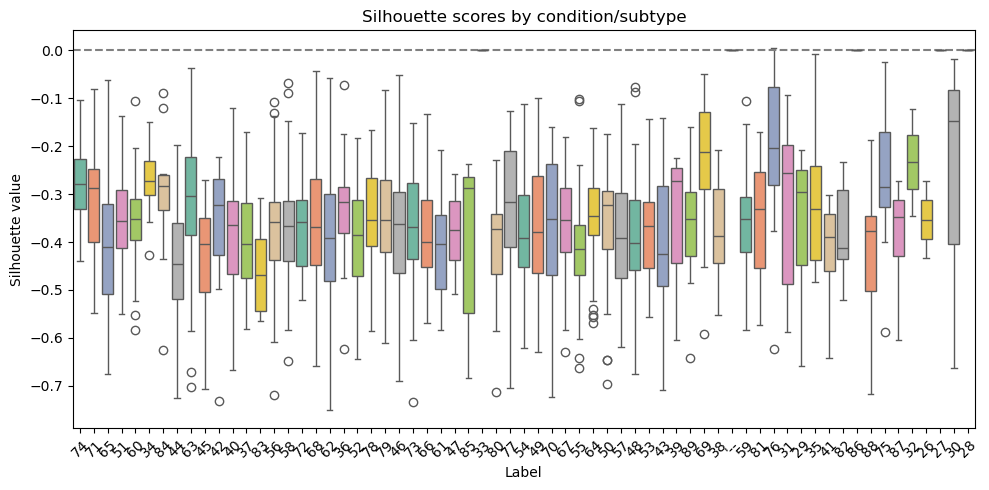

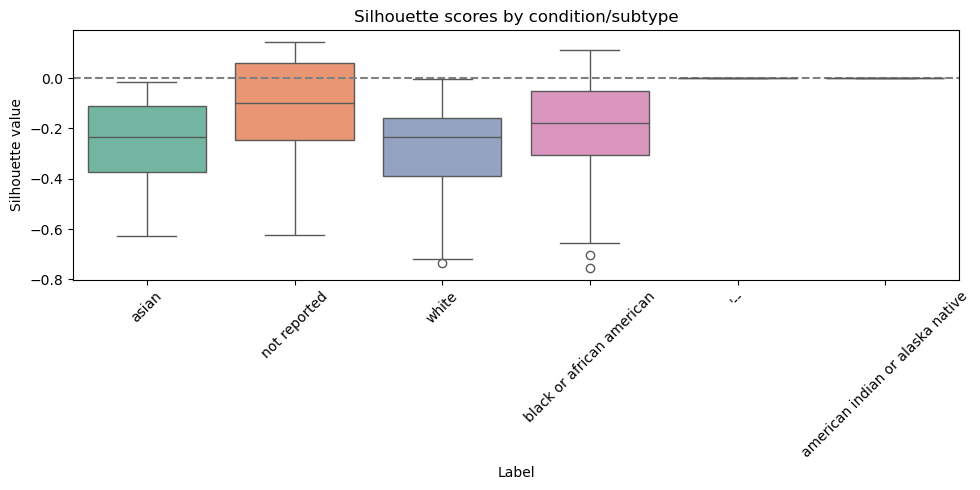

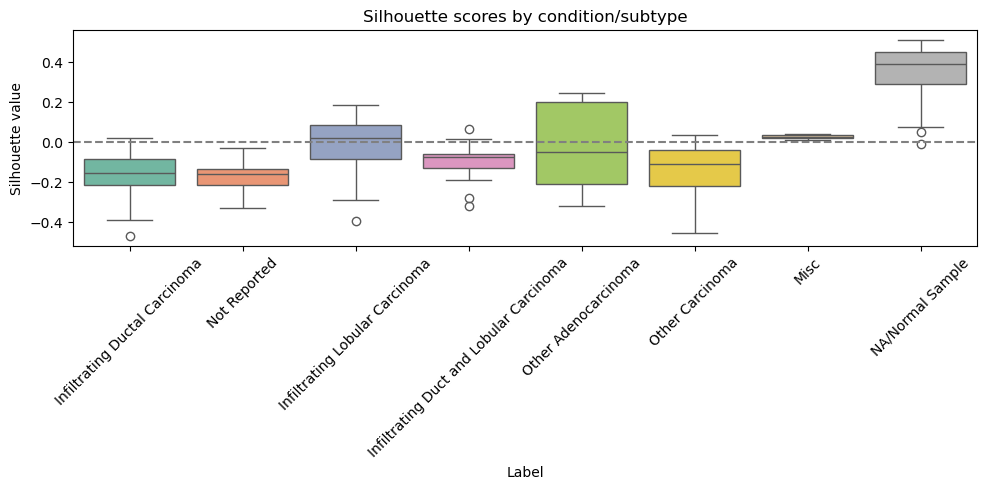

In [66]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Comparison with random

In [67]:
all_genes = list(df.index)

In [68]:
num_rand_genes = len(all_cancer_to_cancer_sig_genes)

In [69]:
num_rand_genes

1373

In [70]:
rand_genes = set()
while len(rand_genes) < num_rand_genes:
    random_idx = random.randint(0, len(all_genes)-1)
    rand_genes.add(all_genes[random_idx])
len(rand_genes)

1373

In [71]:
df_rand = df.loc[list(rand_genes)].copy()

In [72]:
df_for_pca = df_rand.T
log_norm_df = np.log2(df_for_pca + 1)

In [73]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

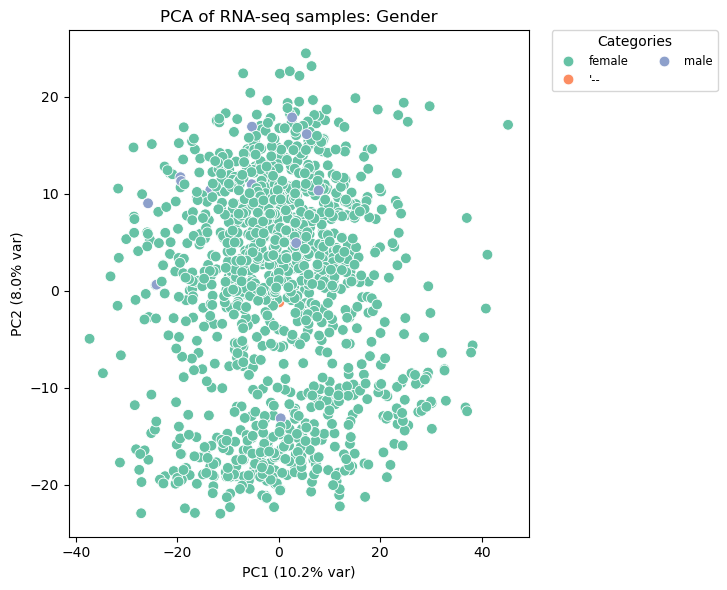

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


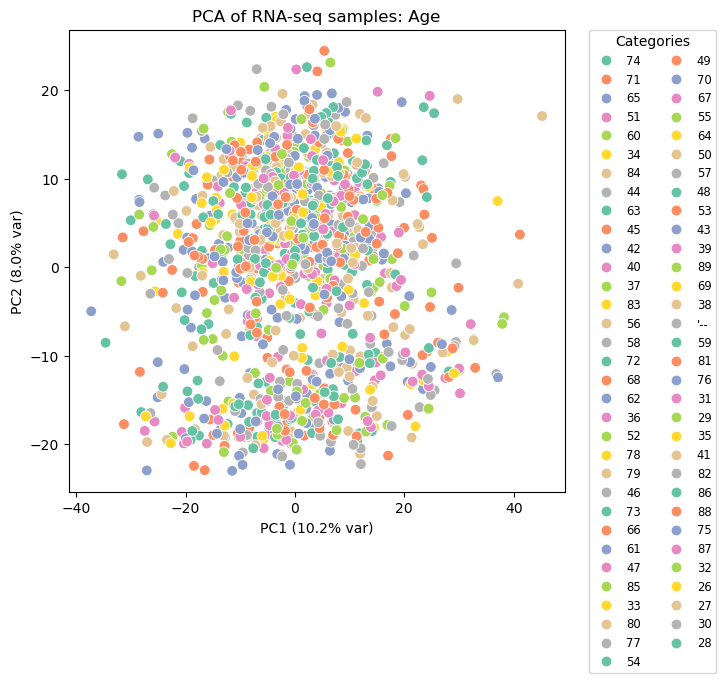

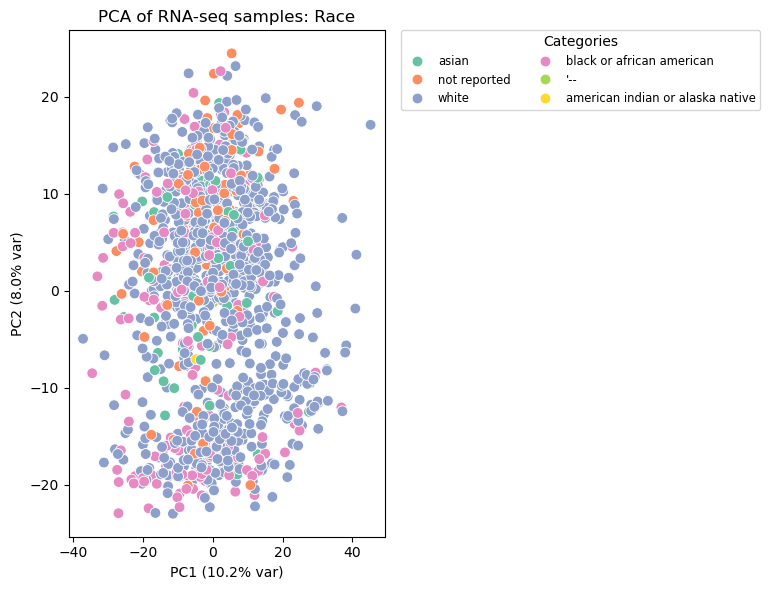

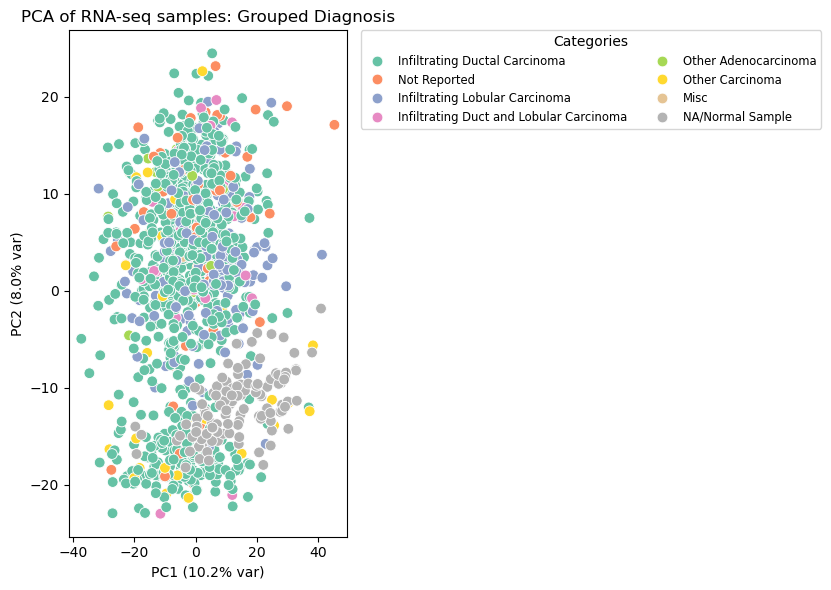

In [74]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [75]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.236
Silhouette Score of Labelling Age: -0.349
Silhouette Score of Labelling Race: -0.242
Silhouette Score of Labelling Grouped Diagnosis: -0.082


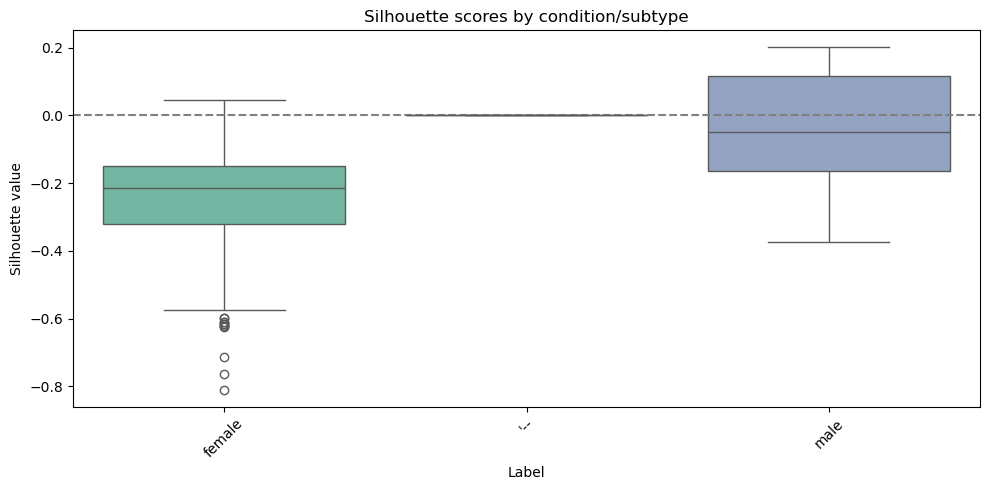

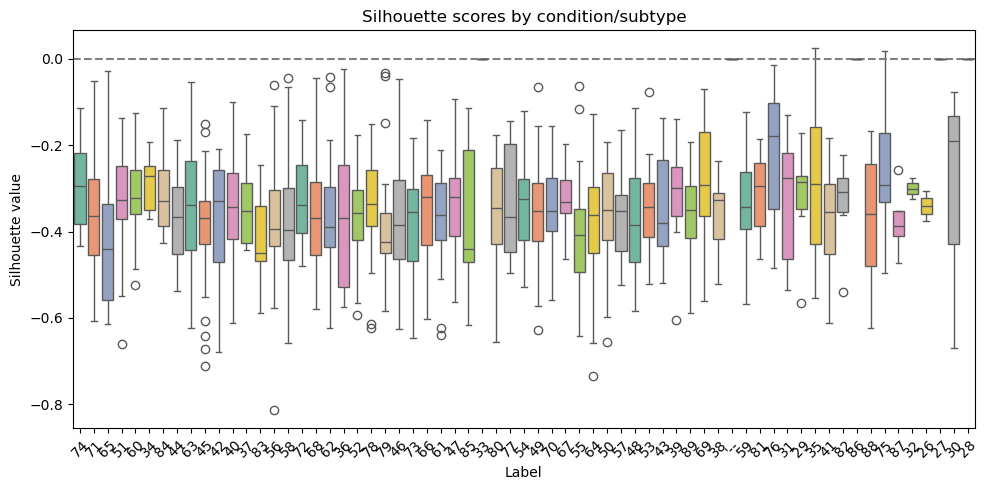

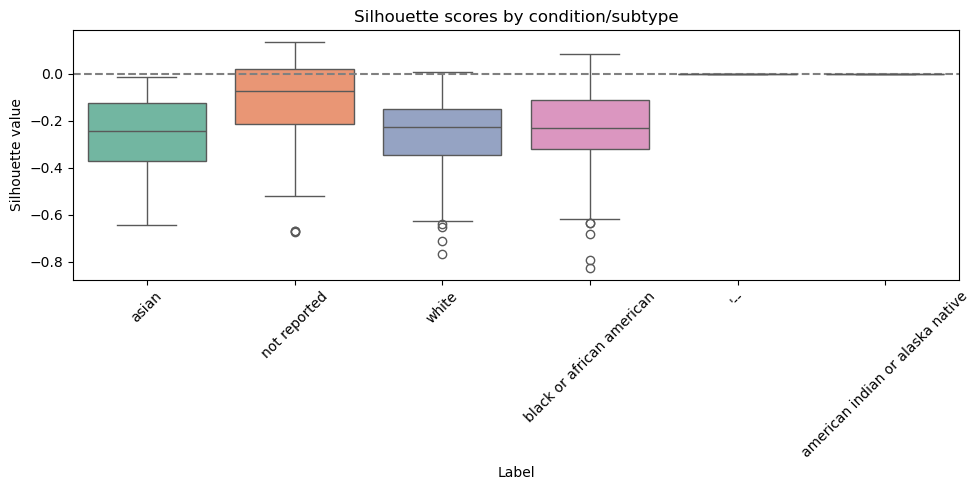

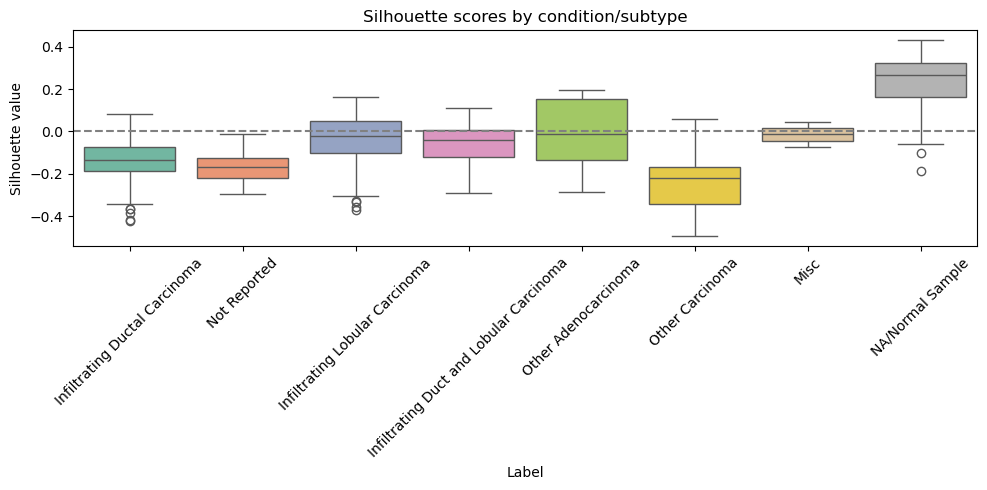

In [76]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

In [77]:
sample_clinical

,Case ID,cases.submitter_id,cases.disease_type,demographic.gender,demographic.age_at_index,demographic.race,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.primary_diagnosis,diagnosis_grouped
Unnamed: 0,,,,,,,,,,
2c3000b7-4db9-4f00-a82a-ca6802806631,TCGA-C8-A1HM,TCGA-C8-A1HM,Ductal and Lobular Neoplasms,female,74,asian,Stage IIA,primary,"Infiltrating duct carcinoma, NOS",Infiltrating Ductal Carcinoma
519b92e0-0dbc-471c-988f-48ce9dc95be3,TCGA-A8-A08S,TCGA-A8-A08S,Ductal and Lobular Neoplasms,female,71,not reported,'--,Prior primary,Not Reported,Not Reported
f2bf29d2-4c33-4810-90e8-88f37ea47bc8,TCGA-AR-A24H,TCGA-AR-A24H,Ductal and Lobular Neoplasms,female,65,white,Stage IIA,primary,"Lobular carcinoma, NOS",Infiltrating Lobular Carcinoma
59858555-bc6a-4286-8280-0f8341123cac,TCGA-AR-A1AH,TCGA-AR-A1AH,Ductal and Lobular Neoplasms,female,51,white,'--,Subsequent Primary,Not Reported,Not Reported
de6f1503-33d7-4f86-b835-bdffba7ea4e3,TCGA-BH-A0BC,TCGA-BH-A0BC,Ductal and Lobular Neoplasms,female,60,white,Stage IIIC,primary,"Infiltrating duct carcinoma, NOS",Infiltrating Ductal Carcinoma
...,...,...,...,...,...,...,...,...,...,...
5e789924-9d98-4765-a348-90a27349d906,TCGA-GI-A2C9,TCGA-GI-A2C9,NA/Normal Sample,female,58,black or african american,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
8a84b9a5-d453-416b-b481-f15402c2eb54,TCGA-BH-A1EU,TCGA-BH-A1EU,NA/Normal Sample,female,83,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
ccb87d7a-2729-4017-bc17-10e5a67bd5cc,TCGA-E2-A15M,TCGA-E2-A15M,NA/Normal Sample,female,66,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample


## Tumor vs Normal

In [88]:
sig_file = "DESeq2Local/results/DiagnosisGrouped_Breast/cancer_vs_normal/sig_genes.csv"
df_genes = pd.read_csv(sig_file, index_col=0)
print(len(df_genes))

5082


In [92]:
df_broad = df.loc[list(df_genes.index.tolist())].copy()

In [94]:
df_broad

,2c3000b7-4db9-4f00-a82a-ca6802806631,519b92e0-0dbc-471c-988f-48ce9dc95be3,f2bf29d2-4c33-4810-90e8-88f37ea47bc8,59858555-bc6a-4286-8280-0f8341123cac,de6f1503-33d7-4f86-b835-bdffba7ea4e3,f0a63361-78bb-4a7f-9d78-31f7b2980ba2,121a48ed-798d-4102-bb8f-e736570e18d6,afedbcf7-d427-4371-9c2a-f349b03de522,82004d79-07d3-4a01-b266-4d36353ba561,4e98f490-cbdf-4864-8cc3-b5f9d3c95146,...,1ce0d66a-176d-4d8a-b1c4-64d847e299be,d757b1cc-31a6-495a-ae82-c63b031ece49,e84b9f1a-0def-425b-86c1-c143b27509b5,b9a1e2f1-e5c4-4855-9720-4c168474dd26,fd94a0ed-37d8-49a5-af96-e2160a9e6096,5e789924-9d98-4765-a348-90a27349d906,8a84b9a5-d453-416b-b481-f15402c2eb54,ccb87d7a-2729-4017-bc17-10e5a67bd5cc,040d00da-2bc9-49d4-bf6c-b4515b6a2bbf,8ebe0bf6-11fa-418d-918c-5c73f0e7e9ac
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000099953.10,2991.0,44780.0,4847.0,15589.0,62468.0,4401.0,17717.0,3225.0,7765.0,38520.0,...,231,277,203,452,154,377,77,303,346,410
ENSG00000101605.13,21.0,55.0,191.0,71.0,148.0,32.0,194.0,557.0,171.0,77.0,...,1649,1978,898,1510,3243,794,470,2228,796,1904
ENSG00000117650.13,3294.0,1345.0,8631.0,2291.0,1804.0,1128.0,1046.0,1999.0,1127.0,620.0,...,68,44,152,89,15,58,12,22,9,829
ENSG00000119927.14,365.0,1746.0,1228.0,1703.0,1176.0,1451.0,3700.0,26441.0,2774.0,770.0,...,22007,69397,29325,26002,86875,4806,9955,9492,4616,50610
ENSG00000123500.10,833.0,11960.0,1024.0,1859.0,10117.0,14031.0,10186.0,899.0,5030.0,11128.0,...,81,96,168,41,36,114,11,49,18,223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000224960.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
ENSG00000124900.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000226372.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,2,0,0,0,0,0,0


In [95]:
df_for_pca = df_broad.T
log_norm_df = np.log2(df_for_pca + 1)

In [96]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [110]:
# Define mapping
group_map = {'Infiltrating Ductal Carcinoma': 'Tumor',
    'Infiltrating Duct and Lobular Carcinoma': 'Tumor',
    'Infiltrating Lobular Carcinoma': 'Tumor',
    'Other Adenocarcinoma': 'Tumor',
    'Other Carcinoma': 'Tumor',
    'Misc': 'Tumor',
    'NA/Normal Sample': 'NA/Normal Sample',
    'Not Reported': 'Not Reported'
}
grouped_diagnosis_key = 'diagnosis_grouped'
pca_df['Classification'] = pca_df['Grouped Diagnosis'].map(group_map).fillna('Not Reported')
sample_clinical['Classification'] =  sample_clinical[grouped_diagnosis_key].map(group_map).fillna('Not Reported')

In [104]:
broad_group_dict = {
    'Gender' : 'demographic.gender',
    'Age': 'demographic.age_at_index',
    'Race': 'demographic.race',
    'Classification': 'Classification'
}

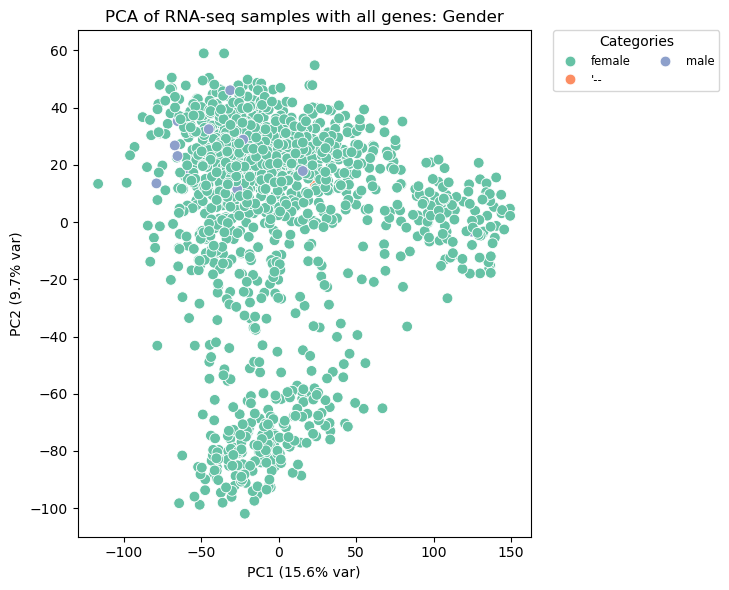

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


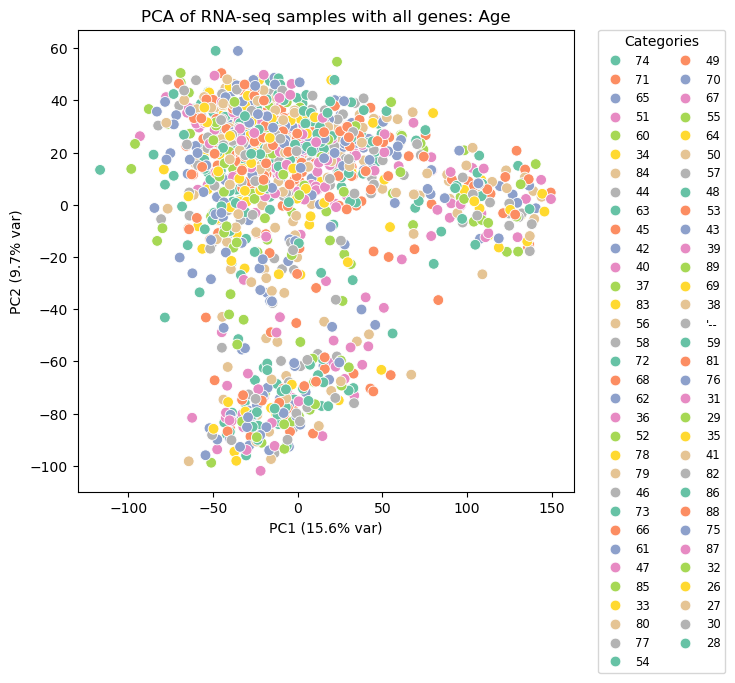

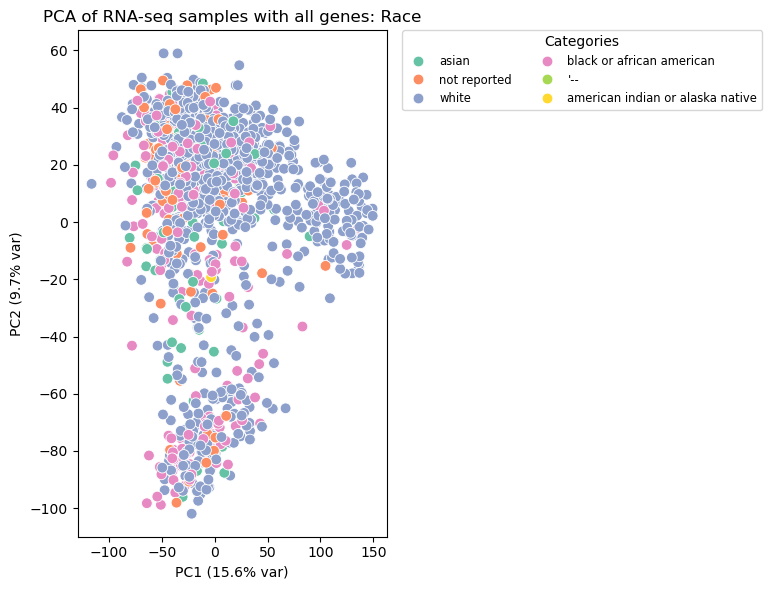

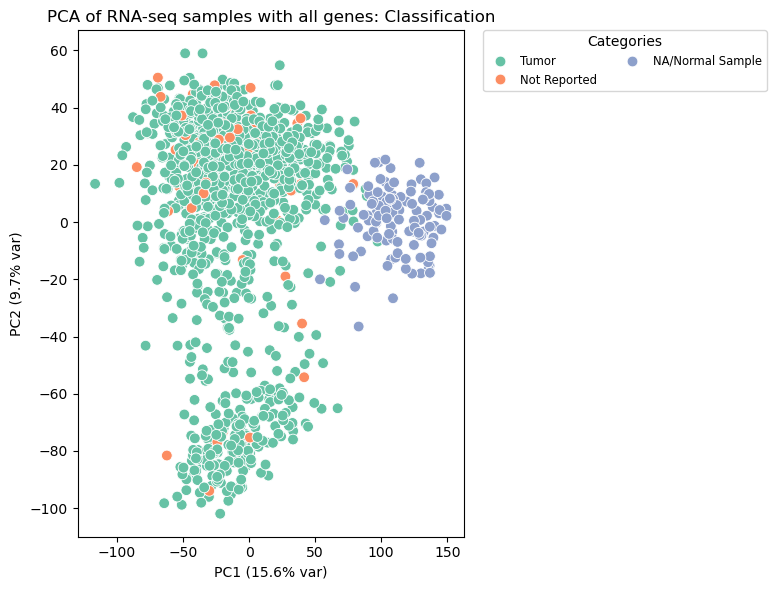

In [107]:
for key in broad_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples with all genes: {key}", f"pca_{broad_group_dict[key].replace(' ', '_')}.png", save = True)

In [111]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in broad_group_dict:
    labels = sample_clinical[broad_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.237
Silhouette Score of Labelling Age: -0.364
Silhouette Score of Labelling Race: -0.251
Silhouette Score of Labelling Classification: 0.039


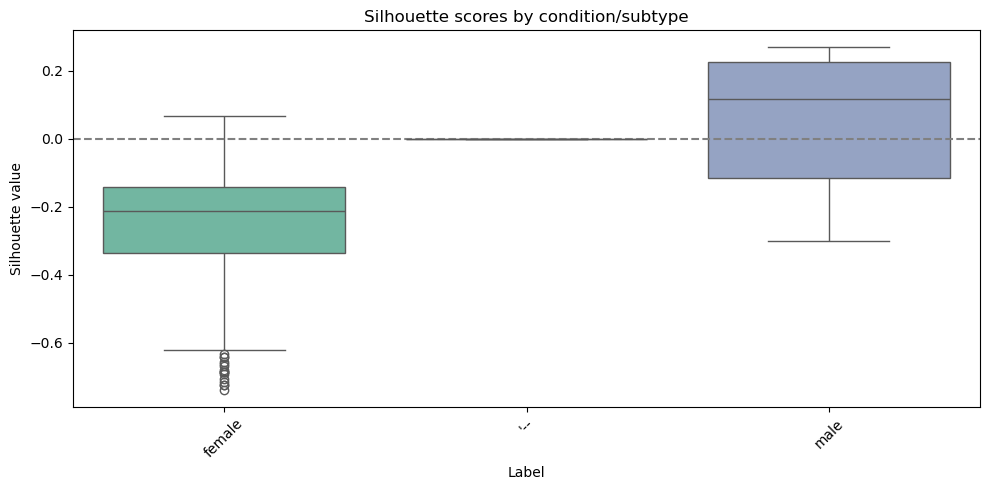

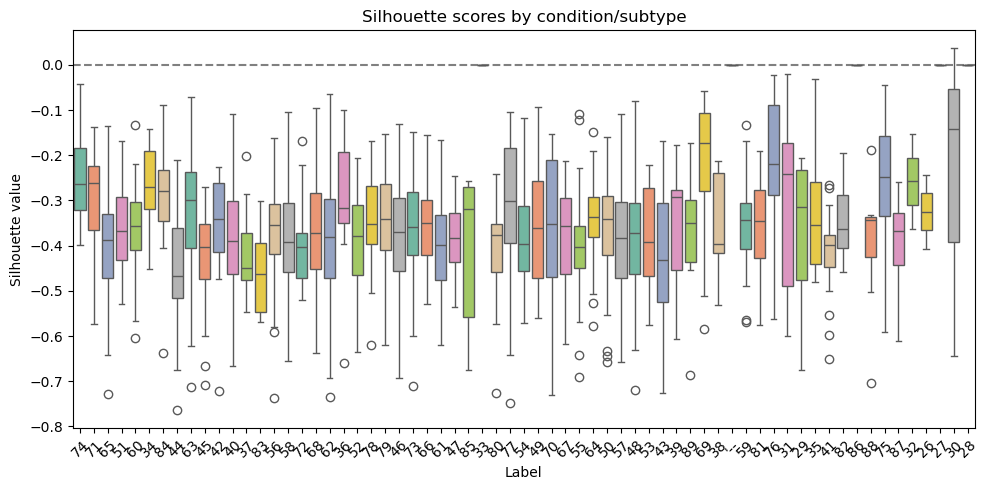

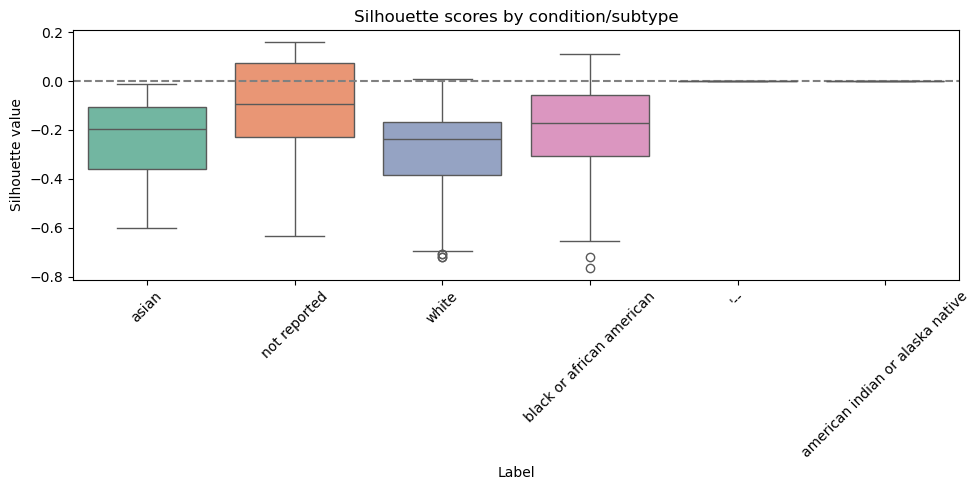

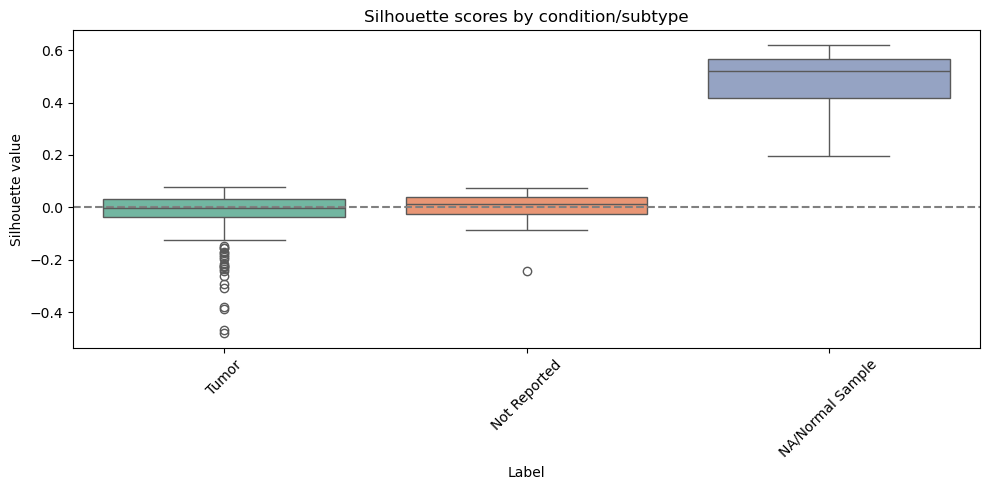

In [112]:
for key in broad_group_dict:
    labels = sample_clinical[broad_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## With all genes

In [113]:
df_for_pca = df.T
log_norm_df = np.log2(df_for_pca + 1)

In [114]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [115]:
# Define mapping
group_map = {'Infiltrating Ductal Carcinoma': 'Tumor',
    'Infiltrating Duct and Lobular Carcinoma': 'Tumor',
    'Infiltrating Lobular Carcinoma': 'Tumor',
    'Other Adenocarcinoma': 'Tumor',
    'Other Carcinoma': 'Tumor',
    'Misc': 'Tumor',
    'NA/Normal Sample': 'NA/Normal Sample',
    'Not Reported': 'Not Reported'
}
grouped_diagnosis_key = 'diagnosis_grouped'
pca_df['Classification'] = pca_df['Grouped Diagnosis'].map(group_map).fillna('Not Reported')
sample_clinical['Classification'] =  sample_clinical[grouped_diagnosis_key].map(group_map).fillna('Not Reported')

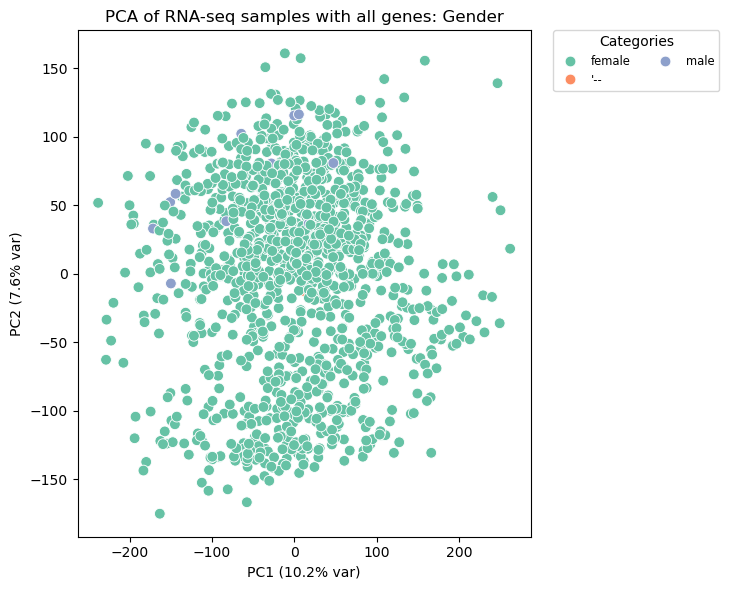

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_72195/2928273651.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


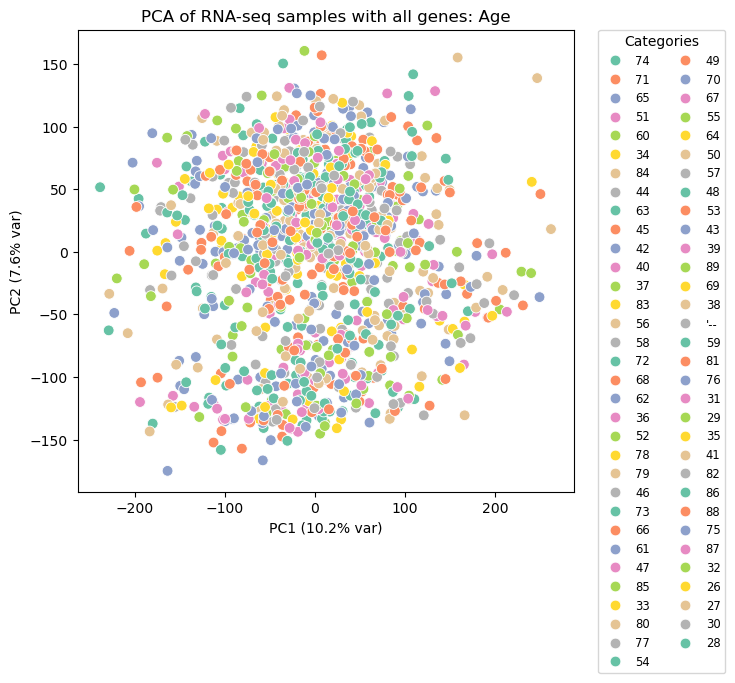

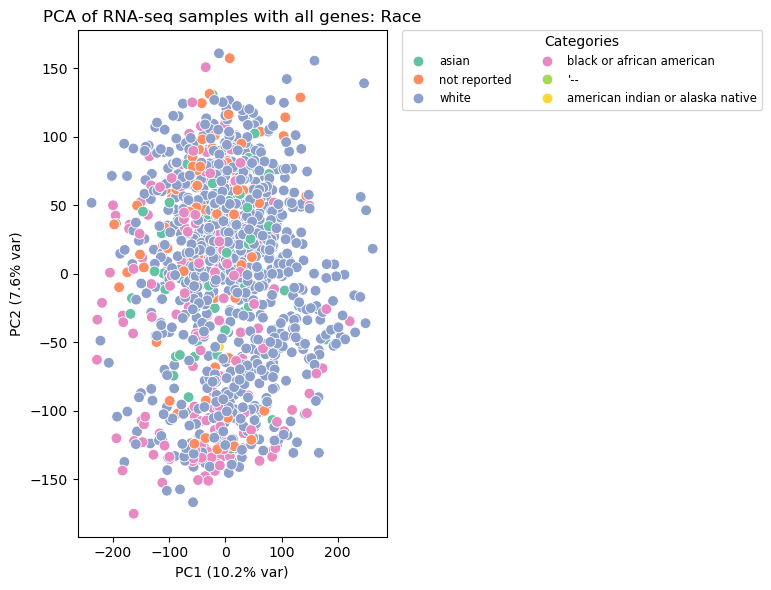

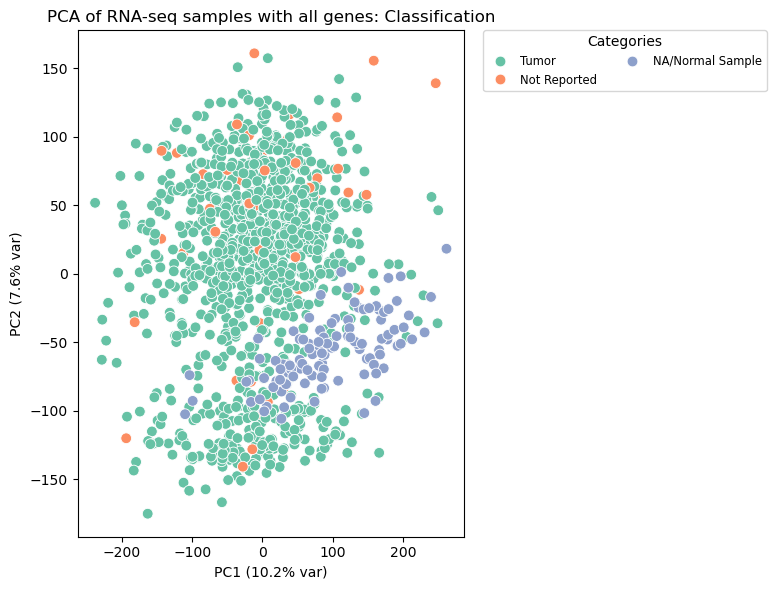

In [116]:
for key in broad_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples with all genes: {key}", f"pca_{broad_group_dict[key].replace(' ', '_')}.png", save = True)

In [117]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in broad_group_dict:
    labels = sample_clinical[broad_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: -0.251
Silhouette Score of Labelling Age: -0.370
Silhouette Score of Labelling Race: -0.249
Silhouette Score of Labelling Classification: 0.057


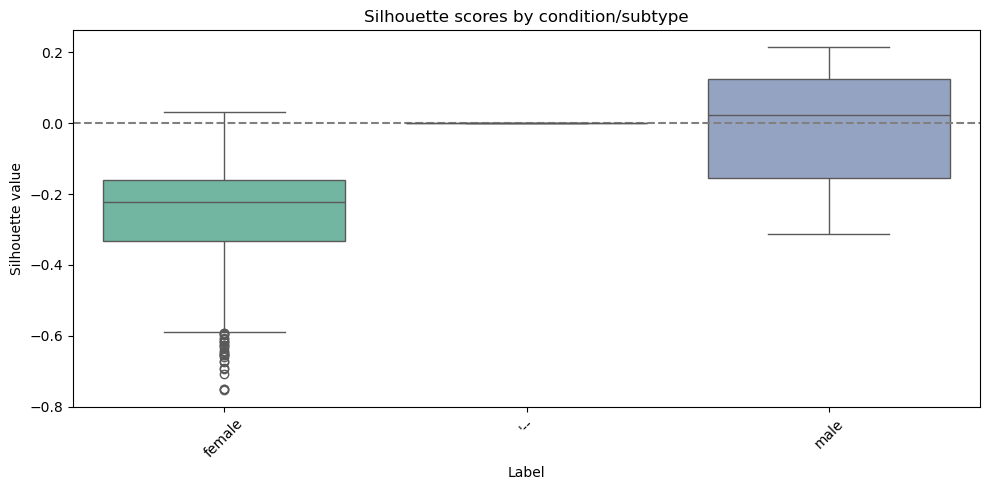

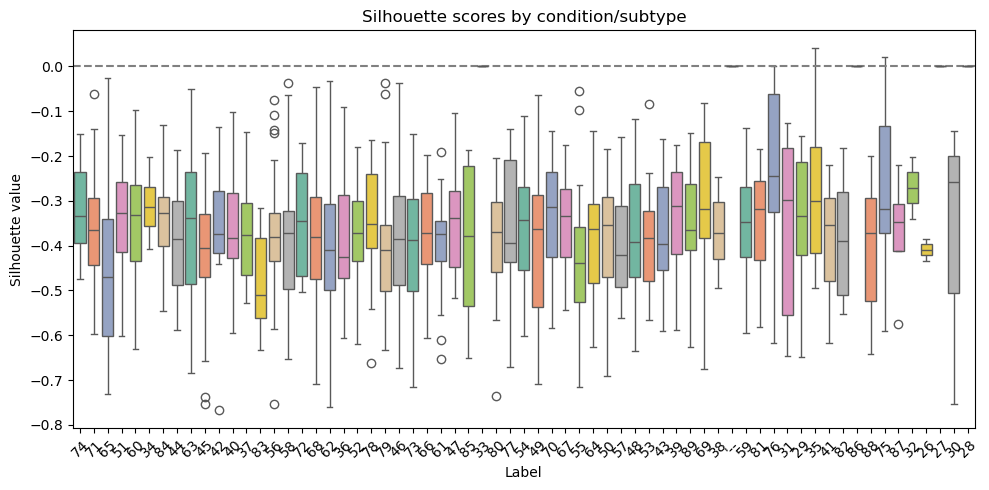

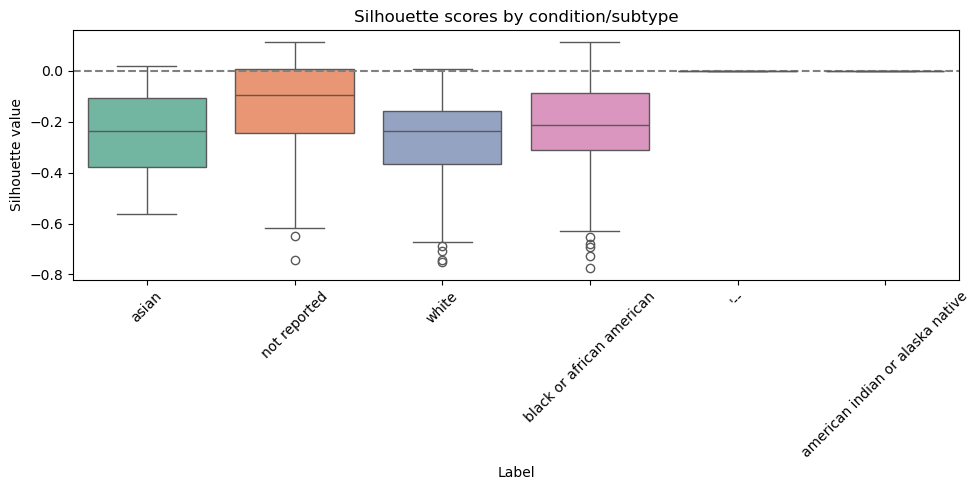

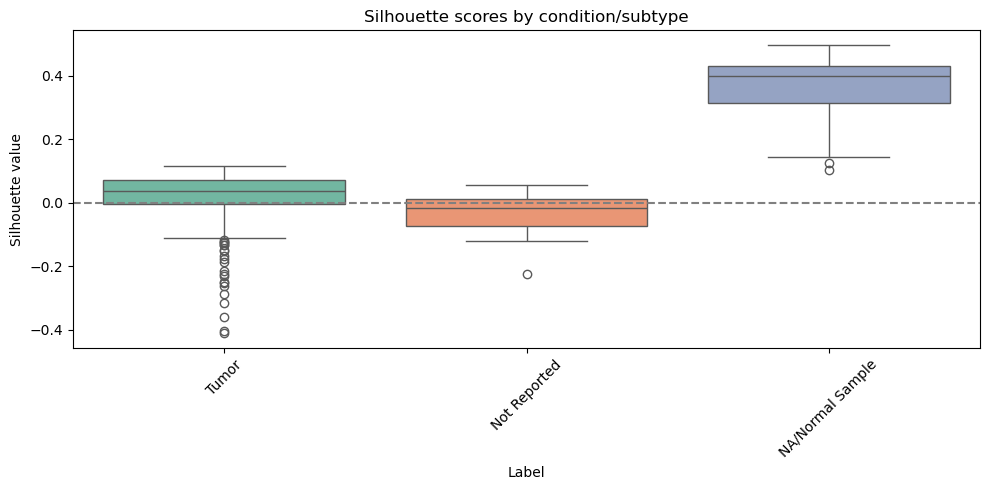

In [118]:
for key in broad_group_dict:
    labels = sample_clinical[broad_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)